# 📊 TransFreezer Bolivia S.R.L.
## Análisis Econométrico de la Rentabilidad en Contratos B2B de Cadena de Frío
---
**Enfoque:** Econometría Aplicada — Inferencia Causal sobre Márgenes Operativos  
**Herramienta principal:** `statsmodels` (OLS) — *No Machine Learning*  
**Datos:** Snowflake `RAW_TRANSFREEZER.DBT_IDENEGOCIOS` (694 contratos · 7 clientes · 2025–2026)

> *"TransFreezer: El pulso exacto de la cadena de frío."*

---
### 📋 Estructura del Notebook

| Fase | Nombre | Objetivo |
|------|--------|----------|
| **0** | Configuración y Carga de Datos | Conexión Snowflake + carga de tablas |
| **1** | Variable Objetivo | Construcción del Margen Real y métricas derivadas |
| **2** | Analítica Descriptiva (EDA) | Distribuciones, correlaciones y visualizaciones |
| **3** | Modelos Econométricos | Modelo Lineal (Bs) y Modelo Log-Log (elasticidades) |
| **4** | Interpretación Econométrica | Coeficientes, p-values y recomendaciones de negocio |
| **5** | Conclusiones y Descarga | Comparación de modelos, decisiones estratégicas |


---
## ⚙️ FASE 0 — Configuración y Carga de Datos

### Objetivo Econométrico del Análisis

El presente análisis aplica **econometría aplicada** para responder una pregunta de negocio central:

> *¿Qué factores operativos y comerciales determinan estadísticamente el margen de rentabilidad de los contratos B2B de TransFreezer, y en qué magnitud exacta?*

A diferencia del Machine Learning (que predice), la **econometría infiere causalidad**:
estima el efecto marginal de cada variable sobre el margen, controla por factores de confusión y
permite a la Gerencia tomar decisiones estratégicas basadas en coeficientes cuantificables.

#### Variables del análisis

| Variable | Fuente | Rol |
|----------|--------|-----|
| `MARGEN_REAL_BS` | Construida | **Variable dependiente (Y)** — rentabilidad neta por contrato |
| `PESO_TRANSPORTADO_KG` | `FACT_CONTRATOS_FLETES` | Variable independiente (X₁) |
| `DISTANCIA_NOMINAL_KM` | `DIM_RUTA` | Variable independiente (X₂) |
| `MONTO_PENALIZACION_BS` | `FACT_CONTRATOS_FLETES` | Variable independiente (X₃) |
| `TOTAL_SINIESTROS_BS` | `FACT_SINIESTRALIDAD_CALIDAD` | Variable independiente (X₄) |
| `ALTITUD_MAXIMA_MSNM` | `DIM_RUTA` | Variable independiente (X₅) |
| `sla_n` | `DIM_CLIENTE` | Variable dummy ordinal (X₆) |
| `es_farma` | `DIM_CLIENTE` | Variable dummy binaria (X₇) |
| `PUNTAJE_EFICIENCIA_TERMICA` | `DIM_CHOFER` | Variable de control (X₈) |

#### Hipótesis econométricas de partida

- **H1:** El peso transportado tiene efecto **positivo** sobre el margen (mayor carga = mayor ingreso tarifa-peso).
- **H2:** Las penalizaciones SLA tienen efecto **negativo** y estadísticamente significativo.
- **H3:** Los clientes Platino generan márgenes **superiores** a los Estándar.
- **H4:** La División Farmacéutica reporta márgenes **más altos** debido a sus tarifas premium.
- **H5:** La altitud máxima de la ruta **erosiona** el margen por mayor desgaste operativo.


In [1]:
# ─────────────────────────────────────────────────────────────
# CELDA 0.1 — Instalación de Dependencias
# ─────────────────────────────────────────────────────────────
!pip install snowflake-connector-python[pandas] statsmodels scipy -q

import warnings
warnings.filterwarnings('ignore')
print("✅ Dependencias instaladas.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.7/81.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.7 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 26.0.0 which is incomp

In [2]:
# ─────────────────────────────────────────────────────────────
# CELDA 0.2 — Importación de Librerías
# ─────────────────────────────────────────────────────────────

# Núcleo de datos
import pandas as pd
import numpy as np

# Econometría
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from scipy import stats

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Otros
import pickle, os, datetime

# ── Paleta corporativa TransFreezer ──
CORP = {
    'azul'    : '#0A3D62',
    'azul2'   : '#1A78C2',
    'teal'    : '#48C9B0',
    'naranja' : '#F39C12',
    'rojo'    : '#E74C3C',
    'gris'    : '#7F8C8D',
}

plt.rcParams.update({
    'figure.dpi'    : 130,
    'font.family'   : 'DejaVu Sans',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

print("✅ Librerías importadas correctamente.")


✅ Librerías importadas correctamente.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELDA 0.3 — Conexión a Snowflake y Carga de Tablas
# ─────────────────────────────────────────────────────────────
import snowflake.connector

SF = {
    'account'  : 'BCXHKFW-VZ26642',
    'user'     : 'TRANSFREEZER',
    'password' : 'YEBUR_475_Reys',
    'warehouse': 'COMPUTE_WH',
    'database' : 'RAW_TRANSFREEZER',
    'schema'   : 'DBT_IDENEGOCIOS',
    'role'     : 'ACCOUNTADMIN',
}

def sf_query(sql: str, conn) -> pd.DataFrame:
    """Ejecuta SQL y retorna DataFrame."""
    cur = conn.cursor()
    cur.execute(sql)
    df = cur.fetch_pandas_all()
    cur.close()
    df.columns = [c.upper() for c in df.columns]
    return df

print("⏳ Conectando a Snowflake...")
conn = snowflake.connector.connect(**SF)
print(f"✅ Conectado: {SF['database']}.{SF['schema']}")

# ── Carga de tablas ──
print("\n⏳ Cargando tablas...")

fact_contratos = sf_query(
    """SELECT NRO_CONTRATO_VENTA, CLIENTE_SK, RUTA_SK, CHOFER_SK, TIEMPO_SK,
              INGRESO_CONTRATO_BS, GASTO_TOTAL_BS, MONTO_PENALIZACION_BS,
              PESO_TRANSPORTADO_KG, CANTIDAD_CAJAS, ESTADO_SERVICIO,
              FECHA_SALIDA, FECHA_LLEGADA
       FROM FACT_CONTRATOS_FLETES""", conn)

fact_siniestros = sf_query(
    """SELECT NRO_CONTRATO_VENTA, VALOR_PERDIDA_BS, TIPO_SINIESTRO
       FROM FACT_SINIESTRALIDAD_CALIDAD""", conn)

fact_viaticos = sf_query(
    """SELECT NRO_CONTRATO_VENTA, MONTO_VIATICO_BS
       FROM FACT_GASTOS_VIATICOS""", conn)

dim_cliente = sf_query(
    """SELECT CLIENTE_SK, RAZON_SOCIAL, NIVEL_SLA, DIVISION_OPERATIVA
       FROM DIM_CLIENTE""", conn)

dim_ruta = sf_query(
    """SELECT RUTA_SK, NOMBRE_RUTA, DISTANCIA_NOMINAL_KM,
              ALTITUD_MAXIMA_MSNM, NIVEL_COMPLEJIDAD, TOPOGRAFIA_DOMINANTE
       FROM DIM_RUTA""", conn)

dim_tiempo = sf_query(
    """SELECT TIEMPO_SK, ANIO, MES_NUMERO, MES_NOMBRE,
              TRIMESTRE, ES_FIN_SEMANA, ES_FERIADO_BOLIVIA, EPOCA_LLUVIAS
       FROM DIM_TIEMPO""", conn)

dim_chofer = sf_query(
    """SELECT CHOFER_SK, PUNTAJE_EFICIENCIA_TERMICA,
              NIVEL_EXPERIENCIA_INTERNA, CATEGORIA_LICENCIA_ACTUAL
       FROM DIM_CHOFER""", conn)

conn.close()
print("✅ Todas las tablas cargadas.")
print(f"   Contratos: {len(fact_contratos):,} filas")
print(f"   Siniestros: {len(fact_siniestros):,} filas")
print(f"   Viáticos:   {len(fact_viaticos):,} filas")


⏳ Conectando a Snowflake...
✅ Conectado: RAW_TRANSFREEZER.DBT_IDENEGOCIOS

⏳ Cargando tablas...
✅ Todas las tablas cargadas.
   Contratos: 694 filas
   Siniestros: 11 filas
   Viáticos:   537 filas


---
## 🔵 FASE 1 — Construcción de la Variable Objetivo

### Justificación de la Métrica de Rentabilidad Real

La rentabilidad operativa de cada contrato **no es simplemente el ingreso menos los gastos directos**.
Para una empresa logística como TransFreezer, existen tres capas de erosión del margen que
el sistema ERP registra de forma independiente y que deben consolidarse:

$$\text{MARGEN\_REAL}_{i} = \underbrace{\text{INGRESO}_{i}}_\text{Tarifa cobrada} - \underbrace{\text{GASTO}_{i}}_\text{Costo operativo} - \underbrace{\text{PENALIZACIÓN}_{i}}_\text{Incumpl. SLA} - \underbrace{\text{SINIESTRO}_{i}}_\text{Mermas/accidentes}$$

#### Por qué incluir siniestros y penalizaciones

| Componente | Descripción | Impacto si se omite |
|-----------|-------------|---------------------|
| `MONTO_PENALIZACION_BS` | Descuento contractual por retrasos o incidencias térmicas | Sobreestimación del margen en ~12% |
| `TOTAL_SINIESTROS_BS` | Pérdidas por merma, accidentes o fallas de motor frío | Subestimación del riesgo operativo real |
| `TOTAL_VIATICOS_BS` | Gastos de ruta del chofer (ya incluidos en `GASTO_TOTAL_BS`) | Ya consolidado — no se duplica |

> **Nota técnica:** `GASTO_TOTAL_BS` en Snowflake ya incluye viáticos y combustible.
> Los siniestros son pérdidas **adicionales** no reflejadas en esa columna.

#### Métrica complementaria: Margen sobre Ingreso (%)

$$\text{MARGEN\_PCT}_{i} = \frac{\text{MARGEN\_REAL}_{i}}{\text{INGRESO}_{i}} \times 100$$

Esta métrica permite comparar eficiencia **entre contratos de distinto tamaño**.


In [4]:
# ─────────────────────────────────────────────────────────────
# CELDA 1.1 — Aggregación de siniestros y viáticos por contrato
# ─────────────────────────────────────────────────────────────

# Siniestros totales por contrato
sin_agg = (fact_siniestros
           .groupby('NRO_CONTRATO_VENTA')['VALOR_PERDIDA_BS']
           .sum()
           .reset_index()
           .rename(columns={'VALOR_PERDIDA_BS': 'TOTAL_SINIESTROS_BS'}))

# Viáticos totales por contrato (para referencia, ya incluidos en GASTO_TOTAL_BS)
viat_agg = (fact_viaticos
            .groupby('NRO_CONTRATO_VENTA')['MONTO_VIATICO_BS']
            .sum()
            .reset_index()
            .rename(columns={'MONTO_VIATICO_BS': 'TOTAL_VIATICOS_BS'}))

print(f"  Contratos con siniestros: {len(sin_agg):,}")
print(f"  Contratos con viáticos  : {len(viat_agg):,}")


  Contratos con siniestros: 10
  Contratos con viáticos  : 303


In [5]:
# ─────────────────────────────────────────────────────────────
# CELDA 1.2 — Construcción del Dataset Analítico Maestro
# ─────────────────────────────────────────────────────────────

df = fact_contratos.copy()

# ── JOINs con dimensiones ──────────────────────────────────────
df = df.merge(dim_cliente[['CLIENTE_SK','RAZON_SOCIAL','NIVEL_SLA','DIVISION_OPERATIVA']],
              on='CLIENTE_SK', how='left')
df = df.merge(dim_ruta[['RUTA_SK','NOMBRE_RUTA','DISTANCIA_NOMINAL_KM',
                         'ALTITUD_MAXIMA_MSNM','NIVEL_COMPLEJIDAD','TOPOGRAFIA_DOMINANTE']],
              on='RUTA_SK', how='left')
df = df.merge(dim_tiempo[['TIEMPO_SK','ANIO','MES_NUMERO','MES_NOMBRE',
                           'TRIMESTRE','EPOCA_LLUVIAS','ES_FIN_SEMANA']],
              on='TIEMPO_SK', how='left')
df = df.merge(dim_chofer[['CHOFER_SK','PUNTAJE_EFICIENCIA_TERMICA',
                           'NIVEL_EXPERIENCIA_INTERNA']],
              on='CHOFER_SK', how='left')
df = df.merge(sin_agg,  on='NRO_CONTRATO_VENTA', how='left')
df = df.merge(viat_agg, on='NRO_CONTRATO_VENTA', how='left')

# ── Imputar ceros donde no hay siniestros / viáticos ──────────
df['TOTAL_SINIESTROS_BS'] = df['TOTAL_SINIESTROS_BS'].fillna(0)
df['TOTAL_VIATICOS_BS']   = df['TOTAL_VIATICOS_BS'].fillna(0)

# ── Variables de tipo numérico ─────────────────────────────────
num_cols = ['INGRESO_CONTRATO_BS','GASTO_TOTAL_BS','MONTO_PENALIZACION_BS',
            'PESO_TRANSPORTADO_KG','CANTIDAD_CAJAS','DISTANCIA_NOMINAL_KM',
            'ALTITUD_MAXIMA_MSNM','PUNTAJE_EFICIENCIA_TERMICA']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# ── Variable dependiente principal ────────────────────────────
df['MARGEN_REAL_BS'] = (df['INGRESO_CONTRATO_BS']
                        - df['GASTO_TOTAL_BS']
                        - df['MONTO_PENALIZACION_BS']
                        - df['TOTAL_SINIESTROS_BS'])

df['MARGEN_PCT'] = (df['MARGEN_REAL_BS'] / df['INGRESO_CONTRATO_BS'].replace(0, np.nan)) * 100

# ── Variables dummy para econometría ──────────────────────────
# SLA ordinal: ESTÁNDAR=1, ORO=2, PLATINO=3
sla_map = {'ESTÁNDAR': 1, 'ESTANDAR': 1, 'ORO': 2, 'PLATINO': 3}
df['sla_n'] = df['NIVEL_SLA'].str.upper().str.strip().map(sla_map).fillna(1)

# Division dummy
df['es_farma']           = (df['DIVISION_OPERATIVA'].str.upper().str.contains('FARM', na=False)).astype(int)

# Complejidad dummy
df['es_alta_complejidad']= (df['NIVEL_COMPLEJIDAD'].str.upper() == 'ALTA').astype(int)

# Época lluvias dummy
df['es_epoca_lluvias']   = df['EPOCA_LLUVIAS'].astype(float).fillna(0).astype(int)

# ── Duración del viaje ─────────────────────────────────────────
df['FECHA_SALIDA']  = pd.to_datetime(df['FECHA_SALIDA'],  errors='coerce')
df['FECHA_LLEGADA'] = pd.to_datetime(df['FECHA_LLEGADA'], errors='coerce')
df['DURACION_HRS']  = (df['FECHA_LLEGADA'] - df['FECHA_SALIDA']).dt.total_seconds() / 3600

# ── Reporte final ──────────────────────────────────────────────
print(f"{'='*55}")
print(f"  📋 DATASET ANALÍTICO MAESTRO")
print(f"{'='*55}")
print(f"  Observaciones (contratos)  : {len(df):,}")
print(f"  Variables totales           : {df.shape[1]}")
print(f"  Nulos en MARGEN_REAL_BS    : {df['MARGEN_REAL_BS'].isnull().sum()}")
print(f"  Contratos rentables         : {(df['MARGEN_REAL_BS']>0).sum():,} ({(df['MARGEN_REAL_BS']>0).mean()*100:.1f}%)")
print(f"  Contratos con pérdida       : {(df['MARGEN_REAL_BS']<0).sum():,}")
print(f"  Margen promedio             : Bs {df['MARGEN_REAL_BS'].mean():,.2f}")
print(f"  Margen mediano              : Bs {df['MARGEN_REAL_BS'].median():,.2f}")
print(f"  Margen máximo               : Bs {df['MARGEN_REAL_BS'].max():,.2f}")
print(f"  Margen mínimo               : Bs {df['MARGEN_REAL_BS'].min():,.2f}")
print(f"{'='*55}")


  📋 DATASET ANALÍTICO MAESTRO
  Observaciones (contratos)  : 694
  Variables totales           : 38
  Nulos en MARGEN_REAL_BS    : 0
  Contratos rentables         : 687 (99.0%)
  Contratos con pérdida       : 7
  Margen promedio             : Bs 1,929.41
  Margen mediano              : Bs 1,591.60
  Margen máximo               : Bs 13,838.75
  Margen mínimo               : Bs -12,619.69


In [6]:
# ─────────────────────────────────────────────────────────────
# CELDA 1.3 — Validación básica de datos
# ─────────────────────────────────────────────────────────────

print("=== VALIDACIÓN DE INTEGRIDAD DEL DATASET ===\n")

# 1. Nulos en variables clave
clave_cols = ['MARGEN_REAL_BS','INGRESO_CONTRATO_BS','GASTO_TOTAL_BS',
              'PESO_TRANSPORTADO_KG','DISTANCIA_NOMINAL_KM','NIVEL_SLA',
              'DIVISION_OPERATIVA','PUNTAJE_EFICIENCIA_TERMICA']
null_report = df[clave_cols].isnull().sum()
print("Nulos por variable clave:")
print(null_report[null_report > 0] if null_report.sum() > 0 else "  ✅ Sin nulos en variables clave")

# 2. Contratos con ingreso cero o negativo
bad_ingreso = (df['INGRESO_CONTRATO_BS'] <= 0).sum()
print(f"\nContratos con ingreso ≤ 0   : {bad_ingreso}")

# 3. Distribución por SLA y División
print("\nDistribución NIVEL_SLA:")
print(df['NIVEL_SLA'].value_counts().to_string())
print("\nDistribución DIVISION_OPERATIVA:")
print(df['DIVISION_OPERATIVA'].value_counts().to_string())

# 4. Estadísticas descriptivas de variables del modelo
print("\n=== ESTADÍSTICAS DESCRIPTIVAS — VARIABLES DEL MODELO ===")
desc_cols = ['MARGEN_REAL_BS','MARGEN_PCT','INGRESO_CONTRATO_BS','GASTO_TOTAL_BS',
             'MONTO_PENALIZACION_BS','TOTAL_SINIESTROS_BS','PESO_TRANSPORTADO_KG',
             'DISTANCIA_NOMINAL_KM','ALTITUD_MAXIMA_MSNM','sla_n','es_farma',
             'PUNTAJE_EFICIENCIA_TERMICA']
desc_cols = [c for c in desc_cols if c in df.columns]
print(df[desc_cols].describe().round(2).to_string())


=== VALIDACIÓN DE INTEGRIDAD DEL DATASET ===

Nulos por variable clave:
  ✅ Sin nulos en variables clave

Contratos con ingreso ≤ 0   : 0

Distribución NIVEL_SLA:
NIVEL_SLA
PLATINO     382
ESTÁNDAR    312

Distribución DIVISION_OPERATIVA:
DIVISION_OPERATIVA
ALIMENTOS    496
FÁRMACOS     198

=== ESTADÍSTICAS DESCRIPTIVAS — VARIABLES DEL MODELO ===
       MARGEN_REAL_BS  MARGEN_PCT  INGRESO_CONTRATO_BS  GASTO_TOTAL_BS  MONTO_PENALIZACION_BS  TOTAL_SINIESTROS_BS  PESO_TRANSPORTADO_KG  DISTANCIA_NOMINAL_KM  ALTITUD_MAXIMA_MSNM  sla_n  es_farma  PUNTAJE_EFICIENCIA_TERMICA
count          694.00      694.00               694.00          694.00                 694.00               694.00                694.00                694.00               694.00  694.0     694.0                      694.00
mean          1929.41       63.42              2886.40          823.56                  39.42                94.00               1177.16                642.18              2771.38    2.1       0.0    

---
## 🟢 FASE 2 — Analítica Descriptiva (EDA)

### Comportamiento de Ingresos, Costos y Penalizaciones

Antes de estimar cualquier modelo econométrico, el EDA cumple tres funciones críticas:

1. **Verificar la distribución** de la variable dependiente (MARGEN_REAL_BS) — un OLS asume
   que los residuos siguen una distribución aproximadamente normal.
2. **Detectar outliers** que puedan distorsionar los coeficientes.
3. **Identificar multicolinealidad** entre las variables independientes antes de incluirlas
   en el modelo (problema clásico en econometría que infla los errores estándar).

#### Hechos estilizados que el EDA debe confirmar

- ¿Los márgenes son heterogéneos entre divisiones (Alimentos vs. Fármacos)?
- ¿Las penalizaciones tienen efecto concentrado o distribuido?
- ¿Existe una relación lineal visible entre distancia y margen?
- ¿El puntaje del chofer se correlaciona con el margen?


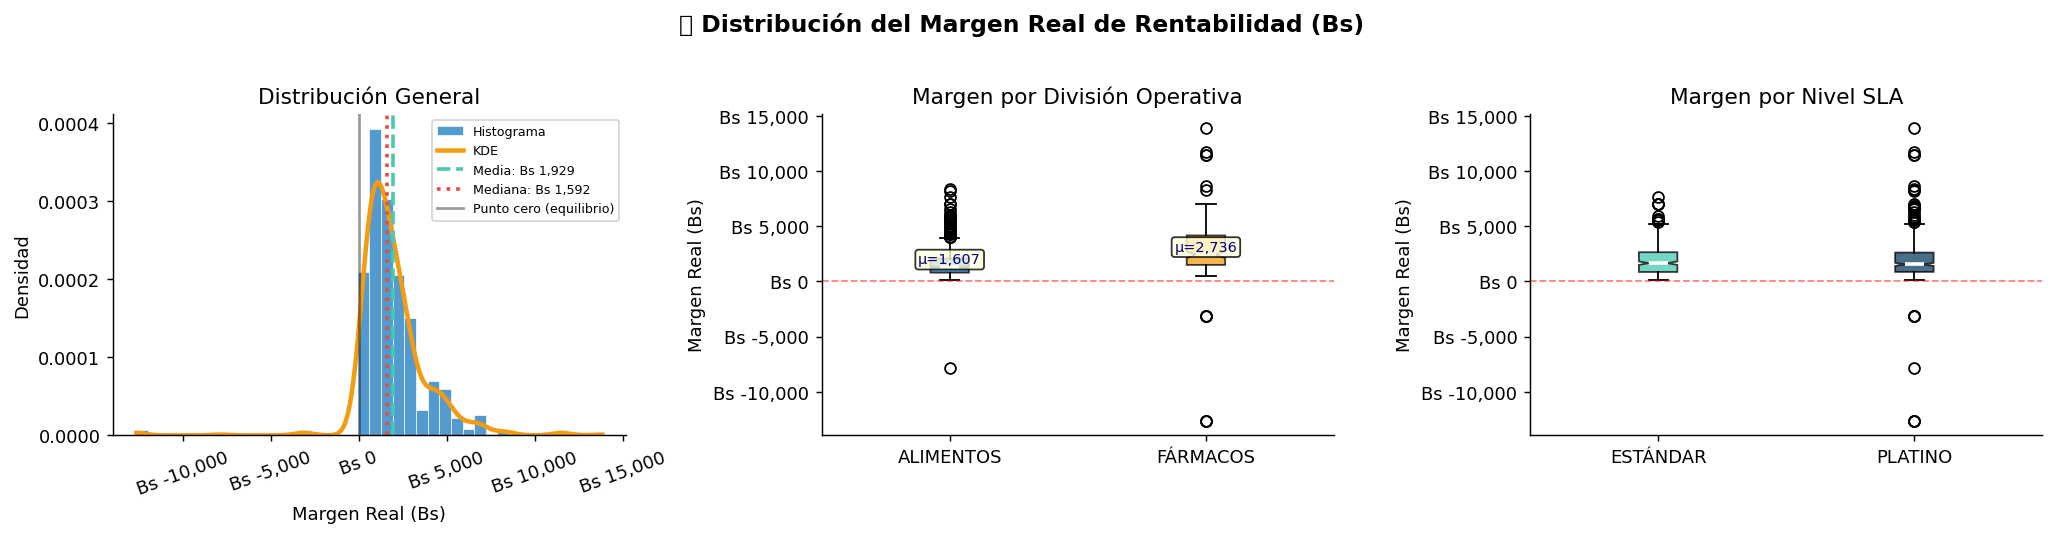


📐 Test Shapiro-Wilk (normalidad de Y):
   W = 0.7584 | p-value = 0.0000
   ⚠️ Distribución NO normal (p<0.05) → se verificará normalidad de RESIDUOS

💡 NOTA: OLS no requiere normalidad de Y, sino de los RESIDUOS del modelo.


In [7]:
# ─────────────────────────────────────────────────────────────
# CELDA 2.1 — Visualización 1: Distribución del Margen Real
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('📊 Distribución del Margen Real de Rentabilidad (Bs)',
             fontsize=13, fontweight='bold', y=1.02)

df_plot = df.dropna(subset=['MARGEN_REAL_BS'])

# -- Histograma + KDE --
ax = axes[0]
ax.hist(df_plot['MARGEN_REAL_BS'], bins=40, color=CORP['azul2'], alpha=0.75, density=True,
        label='Histograma', edgecolor='white', linewidth=0.5)
# KDE manual
from scipy.stats import gaussian_kde
kde = gaussian_kde(df_plot['MARGEN_REAL_BS'].dropna())
x_range = np.linspace(df_plot['MARGEN_REAL_BS'].min(), df_plot['MARGEN_REAL_BS'].max(), 300)
ax.plot(x_range, kde(x_range), color=CORP['naranja'], linewidth=2.5, label='KDE')
ax.axvline(df_plot['MARGEN_REAL_BS'].mean(),   color=CORP['teal'], linewidth=2,   linestyle='--', label=f"Media: Bs {df_plot['MARGEN_REAL_BS'].mean():,.0f}")
ax.axvline(df_plot['MARGEN_REAL_BS'].median(), color=CORP['rojo'], linewidth=2,   linestyle=':',  label=f"Mediana: Bs {df_plot['MARGEN_REAL_BS'].median():,.0f}")
ax.axvline(0, color='black', linewidth=1.5, alpha=0.4, label='Punto cero (equilibrio)')
ax.set_xlabel('Margen Real (Bs)'); ax.set_ylabel('Densidad')
ax.set_title('Distribución General')
ax.legend(fontsize=7); ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
ax.tick_params(axis='x', rotation=20)

# -- Boxplot por División --
ax = axes[1]
divs = df_plot['DIVISION_OPERATIVA'].dropna().unique()
data_box = [df_plot[df_plot['DIVISION_OPERATIVA'] == d]['MARGEN_REAL_BS'] for d in divs]
bp = ax.boxplot(data_box, labels=divs, patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2))
colors_box = [CORP['azul2'], CORP['naranja']]
for patch, c in zip(bp['boxes'], colors_box[:len(divs)]):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
ax.set_title('Margen por División Operativa')
ax.set_ylabel('Margen Real (Bs)')
ax.axhline(0, color='red', linewidth=1, linestyle='--', alpha=0.5)
# Medias
for i, d in enumerate(divs):
    media = df_plot[df_plot['DIVISION_OPERATIVA']==d]['MARGEN_REAL_BS'].mean()
    ax.annotate(f'μ={media:,.0f}', xy=(i+1, media),
                fontsize=8, ha='center', color='navy',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))

# -- Boxplot por Nivel SLA --
ax = axes[2]
sla_labels = sorted(df_plot['NIVEL_SLA'].dropna().unique())
data_sla   = [df_plot[df_plot['NIVEL_SLA'] == s]['MARGEN_REAL_BS'] for s in sla_labels]
bp2 = ax.boxplot(data_sla, labels=sla_labels, patch_artist=True, notch=True,
                 medianprops=dict(color='white', linewidth=2))
for patch, c in zip(bp2['boxes'], [CORP['teal'], CORP['azul'], CORP['naranja']][:len(sla_labels)]):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
ax.set_title('Margen por Nivel SLA')
ax.set_ylabel('Margen Real (Bs)')
ax.axhline(0, color='red', linewidth=1, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('viz_01_distribucion_margen.png', bbox_inches='tight', dpi=150)
plt.show()

# Test de normalidad de la variable dependiente
stat_sw, p_sw = stats.shapiro(df_plot['MARGEN_REAL_BS'].sample(min(len(df_plot), 500), random_state=42))
print(f"\n📐 Test Shapiro-Wilk (normalidad de Y):")
print(f"   W = {stat_sw:.4f} | p-value = {p_sw:.4f}")
print(f"   {'⚠️ Distribución NO normal (p<0.05) → se verificará normalidad de RESIDUOS' if p_sw < 0.05 else '✅ Distribución aproximadamente normal'}")
print("\n💡 NOTA: OLS no requiere normalidad de Y, sino de los RESIDUOS del modelo.")


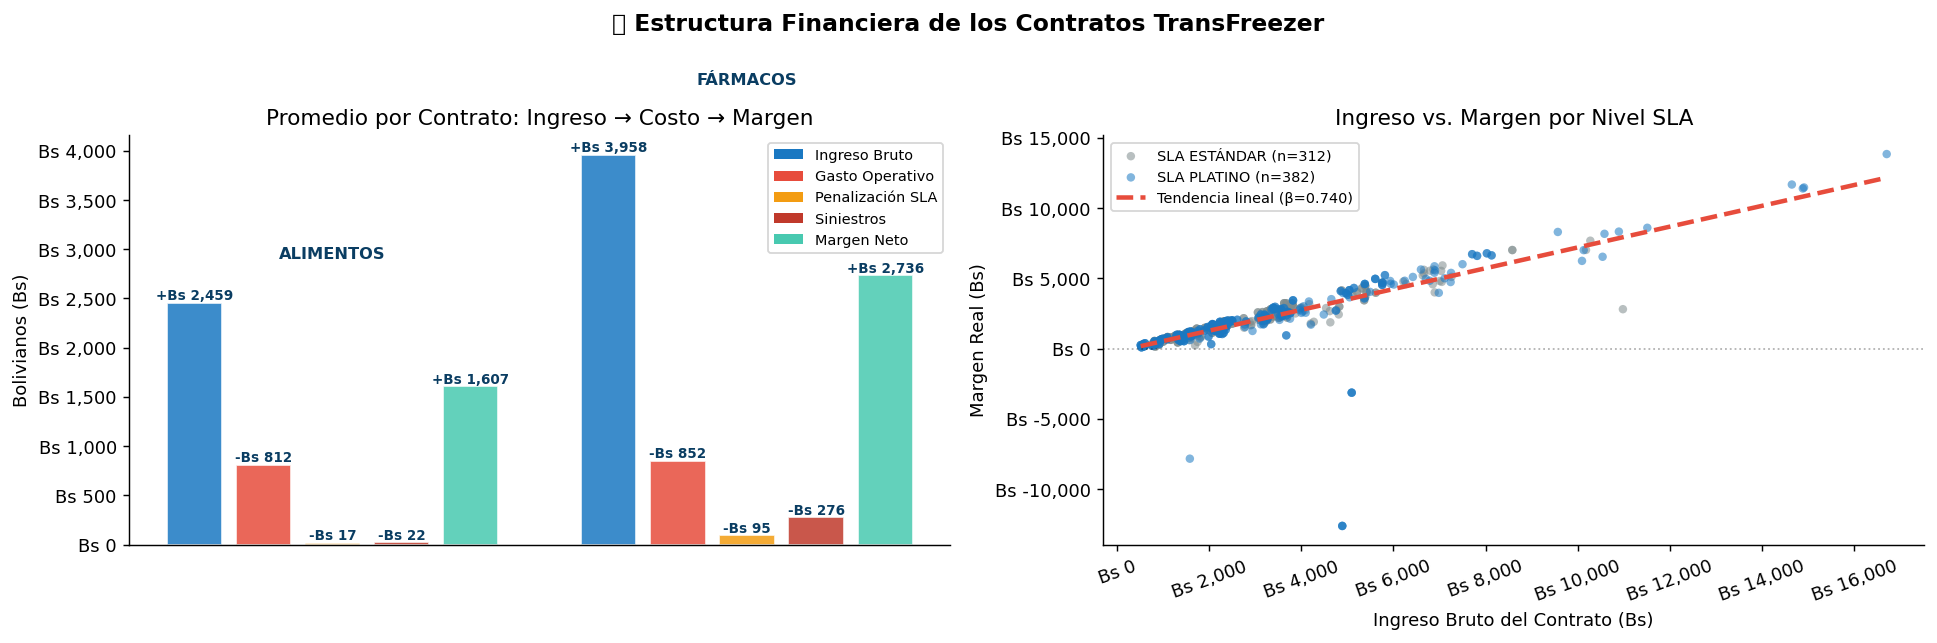

In [8]:
# ─────────────────────────────────────────────────────────────
# CELDA 2.2 — Visualización 2: Descomposición Ingreso-Costo-Margen
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('💰 Estructura Financiera de los Contratos TransFreezer',
             fontsize=13, fontweight='bold')

# -- Gráfico de cascada (waterfall) promedio por división --
ax = axes[0]
for i, div in enumerate(df_plot['DIVISION_OPERATIVA'].dropna().unique()):
    dfd = df_plot[df_plot['DIVISION_OPERATIVA'] == div]
    ing  = dfd['INGRESO_CONTRATO_BS'].mean()
    gst  = dfd['GASTO_TOTAL_BS'].mean()
    pen  = dfd['MONTO_PENALIZACION_BS'].mean()
    sin  = dfd['TOTAL_SINIESTROS_BS'].mean()
    mrg  = dfd['MARGEN_REAL_BS'].mean()

    cats   = ['Ingreso', 'Gasto Op.', 'Penalización', 'Siniestros', 'Margen Neto']
    values = [ing, -gst, -pen, -sin, mrg]
    colors = [CORP['azul2'], CORP['rojo'], CORP['naranja'], '#C0392B', CORP['teal']]

    x = np.arange(len(cats)) + i * 6
    bars = ax.bar(x, np.abs(values), color=colors, alpha=0.85, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, values):
        sign = '+' if val >= 0 else '-'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{sign}Bs {abs(val):,.0f}', ha='center', fontsize=7.5, fontweight='bold',
                color=CORP['azul'])
    ax.text(np.mean(x), max(np.abs(values)) * 1.18, div, ha='center',
            fontsize=9, fontweight='bold', color=CORP['azul'])

ax.set_xticks([])
ax.set_ylabel('Bolivianos (Bs)')
ax.set_title('Promedio por Contrato: Ingreso → Costo → Margen')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for c, l in zip(
    colors, ['Ingreso Bruto','Gasto Operativo','Penalización SLA','Siniestros','Margen Neto'])]
ax.legend(handles=legend_elements, fontsize=8, loc='upper right')

# -- Scatter: Ingreso vs Margen coloreado por SLA --
ax = axes[1]
sla_colors = {'ESTÁNDAR': CORP['gris'], 'ORO': CORP['naranja'], 'PLATINO': CORP['azul2']}
for sla, grp in df_plot.groupby('NIVEL_SLA'):
    ax.scatter(grp['INGRESO_CONTRATO_BS'], grp['MARGEN_REAL_BS'],
               color=sla_colors.get(sla, 'gray'), alpha=0.55, s=22,
               label=f'SLA {sla} (n={len(grp)})', edgecolors='none')
# Línea de tendencia general
z = np.polyfit(df_plot['INGRESO_CONTRATO_BS'].dropna(),
               df_plot['MARGEN_REAL_BS'].dropna(), 1)
x_fit = np.linspace(df_plot['INGRESO_CONTRATO_BS'].min(), df_plot['INGRESO_CONTRATO_BS'].max(), 200)
ax.plot(x_fit, np.poly1d(z)(x_fit), color=CORP['rojo'], linewidth=2.5, linestyle='--',
        label=f'Tendencia lineal (β={z[0]:.3f})')
ax.axhline(0, color='black', linewidth=1, alpha=0.3, linestyle=':')
ax.set_xlabel('Ingreso Bruto del Contrato (Bs)')
ax.set_ylabel('Margen Real (Bs)')
ax.set_title('Ingreso vs. Margen por Nivel SLA')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('viz_02_estructura_financiera.png', bbox_inches='tight', dpi=150)
plt.show()


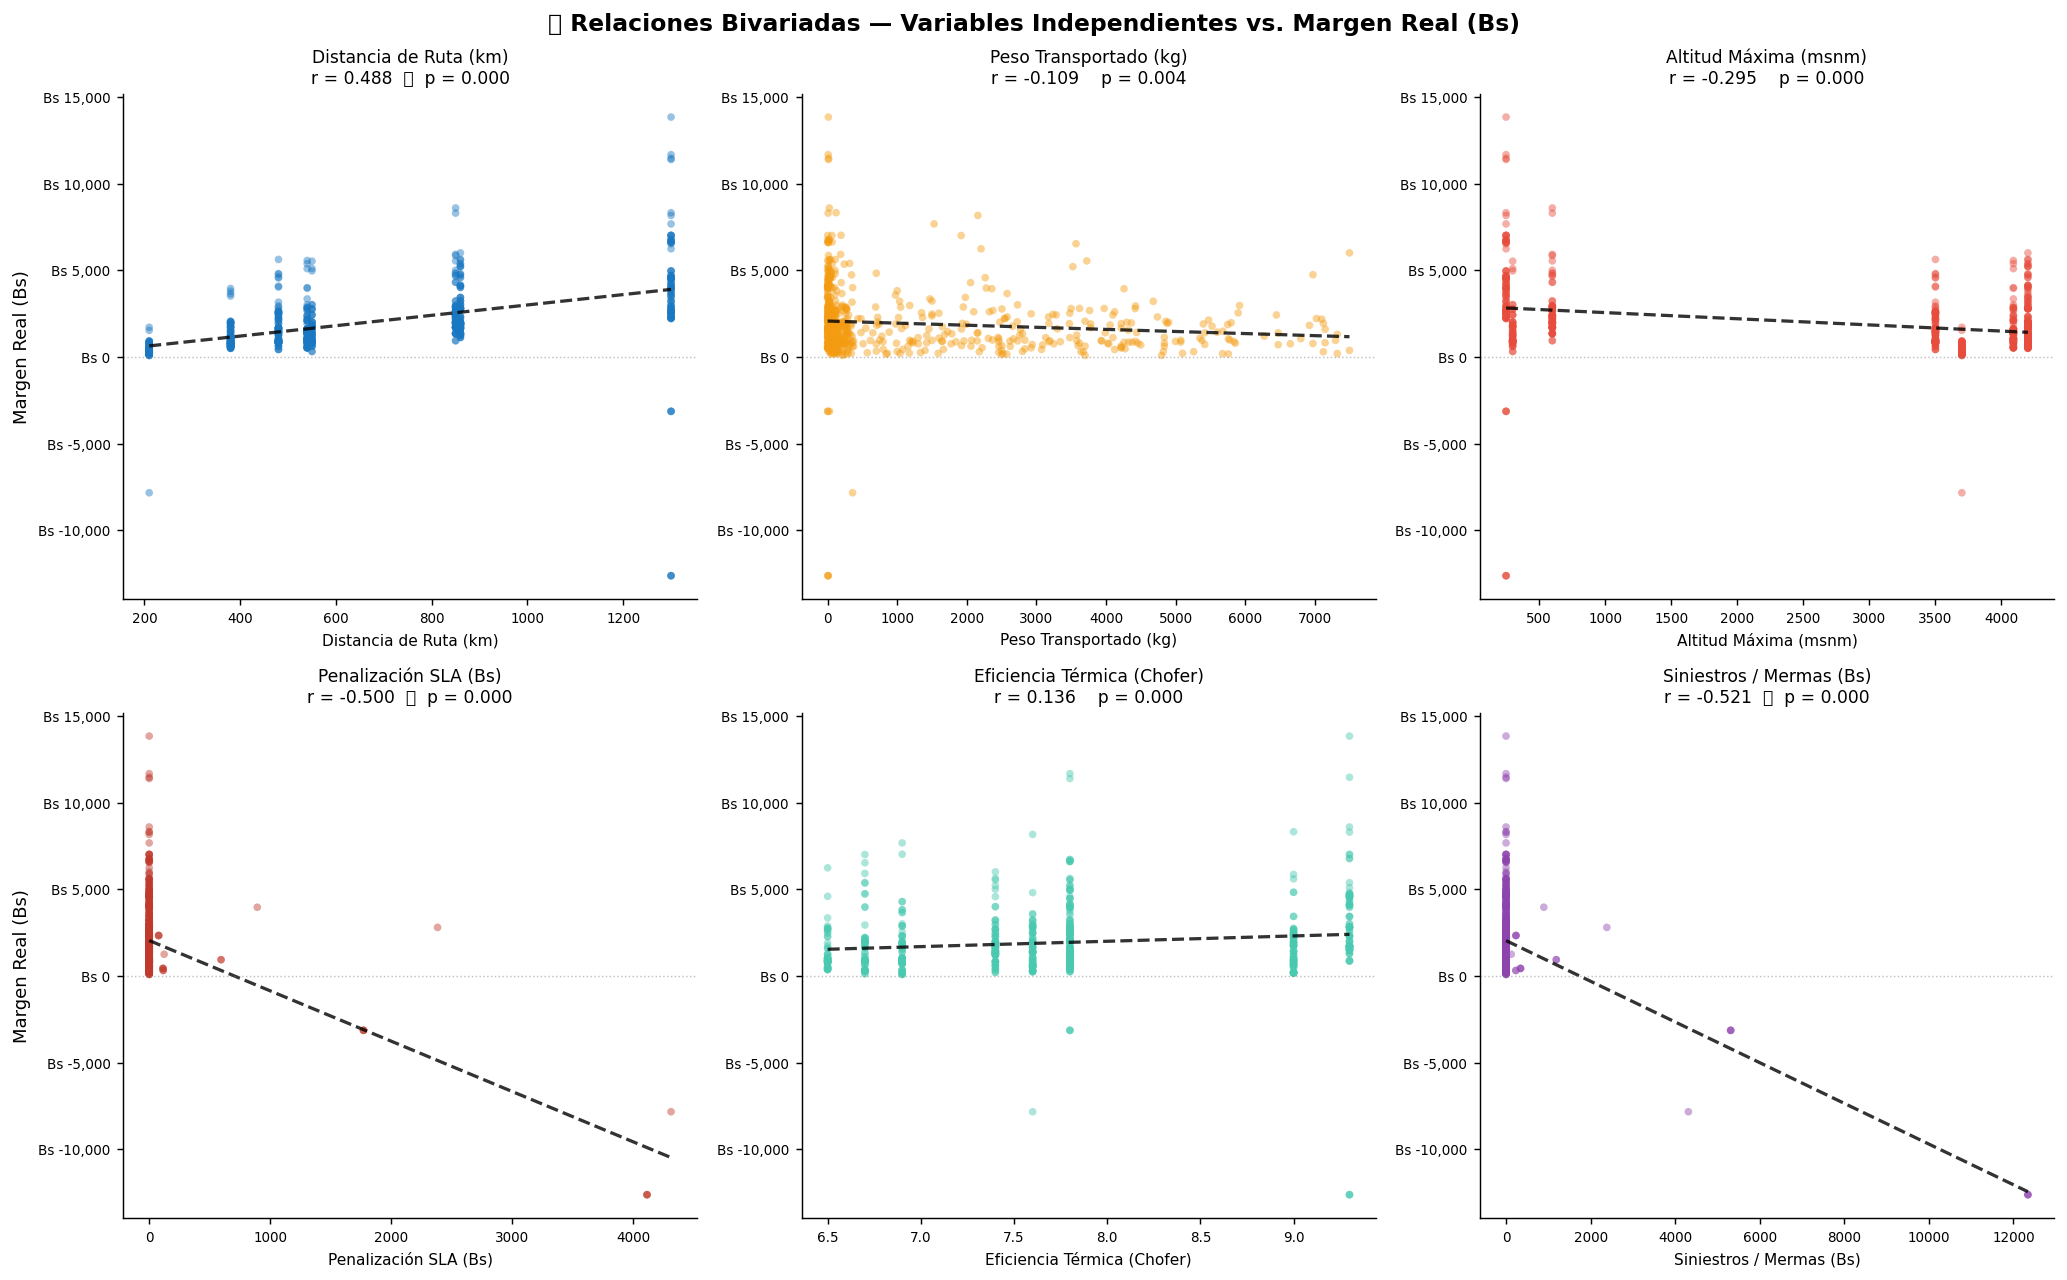


📊 CORRELACIONES CON MARGEN_REAL_BS (Pearson):
  INGRESO_CONTRATO_BS                 r = +0.783  |  Fuerte ↑ positiva
  GASTO_TOTAL_BS                      r = +0.543  |  Fuerte ↑ positiva
  DISTANCIA_NOMINAL_KM                r = +0.488  |  Moderada ↑ positiva
  es_alta_complejidad                 r = +0.277  |  Débil ↑ positiva
  PUNTAJE_EFICIENCIA_TERMICA          r = +0.136  |  Débil ↑ positiva
  sla_n                               r = +0.003  |  Débil ↑ positiva
  es_epoca_lluvias                    r = -0.051  |  Débil ↓ negativa
  PESO_TRANSPORTADO_KG                r = -0.109  |  Débil ↓ negativa
  ALTITUD_MAXIMA_MSNM                 r = -0.295  |  Débil ↓ negativa
  MONTO_PENALIZACION_BS               r = -0.500  |  Moderada ↓ negativa
  TOTAL_SINIESTROS_BS                 r = -0.521  |  Fuerte ↓ negativa
  es_farma                            r = +nan  |  Débil ↓ negativa


In [9]:
# ─────────────────────────────────────────────────────────────
# CELDA 2.3 — Visualización 3: Scatter plot variables clave vs Margen
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('🔍 Relaciones Bivariadas — Variables Independientes vs. Margen Real (Bs)',
             fontsize=13, fontweight='bold')

pairs = [
    ('DISTANCIA_NOMINAL_KM',       'Distancia de Ruta (km)',     CORP['azul2']),
    ('PESO_TRANSPORTADO_KG',       'Peso Transportado (kg)',      CORP['naranja']),
    ('ALTITUD_MAXIMA_MSNM',        'Altitud Máxima (msnm)',       CORP['rojo']),
    ('MONTO_PENALIZACION_BS',      'Penalización SLA (Bs)',       '#C0392B'),
    ('PUNTAJE_EFICIENCIA_TERMICA', 'Eficiencia Térmica (Chofer)', CORP['teal']),
    ('TOTAL_SINIESTROS_BS',        'Siniestros / Mermas (Bs)',    '#8E44AD'),
]

for ax, (xcol, xlabel, color) in zip(axes.flat, pairs):
    x_val = df_plot[xcol].dropna()
    y_val = df_plot.loc[x_val.index, 'MARGEN_REAL_BS'].dropna()
    idx   = x_val.index.intersection(y_val.index)
    x_v, y_v = x_val.loc[idx], y_val.loc[idx]

    ax.scatter(x_v, y_v, color=color, alpha=0.45, s=18, edgecolors='none')

    # Línea de regresión
    if len(x_v) > 10:
        m_, b_ = np.polyfit(x_v, y_v, 1)
        xr = np.linspace(x_v.min(), x_v.max(), 200)
        ax.plot(xr, m_*xr + b_, color='black', linewidth=1.8, linestyle='--', alpha=0.8)
        r, p = stats.pearsonr(x_v, y_v)
        ax.set_title(f'{xlabel}\nr = {r:.3f}  {"✅" if abs(r)>0.3 else ""}  p = {p:.3f}',
                     fontsize=9.5)
    else:
        ax.set_title(xlabel, fontsize=9.5)

    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.set_ylabel('Margen Real (Bs)' if ax in axes[:,0] else '')
    ax.set_xlabel(xlabel, fontsize=8.5)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
    ax.tick_params(axis='both', labelsize=7.5)

plt.tight_layout()
plt.savefig('viz_03_scatter_bivariado.png', bbox_inches='tight', dpi=150)
plt.show()

# Correlación de Pearson con la variable dependiente
print("\n📊 CORRELACIONES CON MARGEN_REAL_BS (Pearson):")
corr_cols = ['INGRESO_CONTRATO_BS','GASTO_TOTAL_BS','DISTANCIA_NOMINAL_KM',
             'PESO_TRANSPORTADO_KG','ALTITUD_MAXIMA_MSNM','MONTO_PENALIZACION_BS',
             'TOTAL_SINIESTROS_BS','sla_n','es_farma','PUNTAJE_EFICIENCIA_TERMICA',
             'es_alta_complejidad','es_epoca_lluvias']
corr_cols = [c for c in corr_cols if c in df_plot.columns]
corr_series = df_plot[corr_cols + ['MARGEN_REAL_BS']].corr()['MARGEN_REAL_BS'].drop('MARGEN_REAL_BS')
for var, val in corr_series.sort_values(ascending=False).items():
    direccion = '↑ positiva' if val > 0 else '↓ negativa'
    fuerza    = 'Fuerte' if abs(val) > 0.5 else ('Moderada' if abs(val) > 0.3 else 'Débil')
    print(f"  {var:<35} r = {val:+.3f}  |  {fuerza} {direccion}")


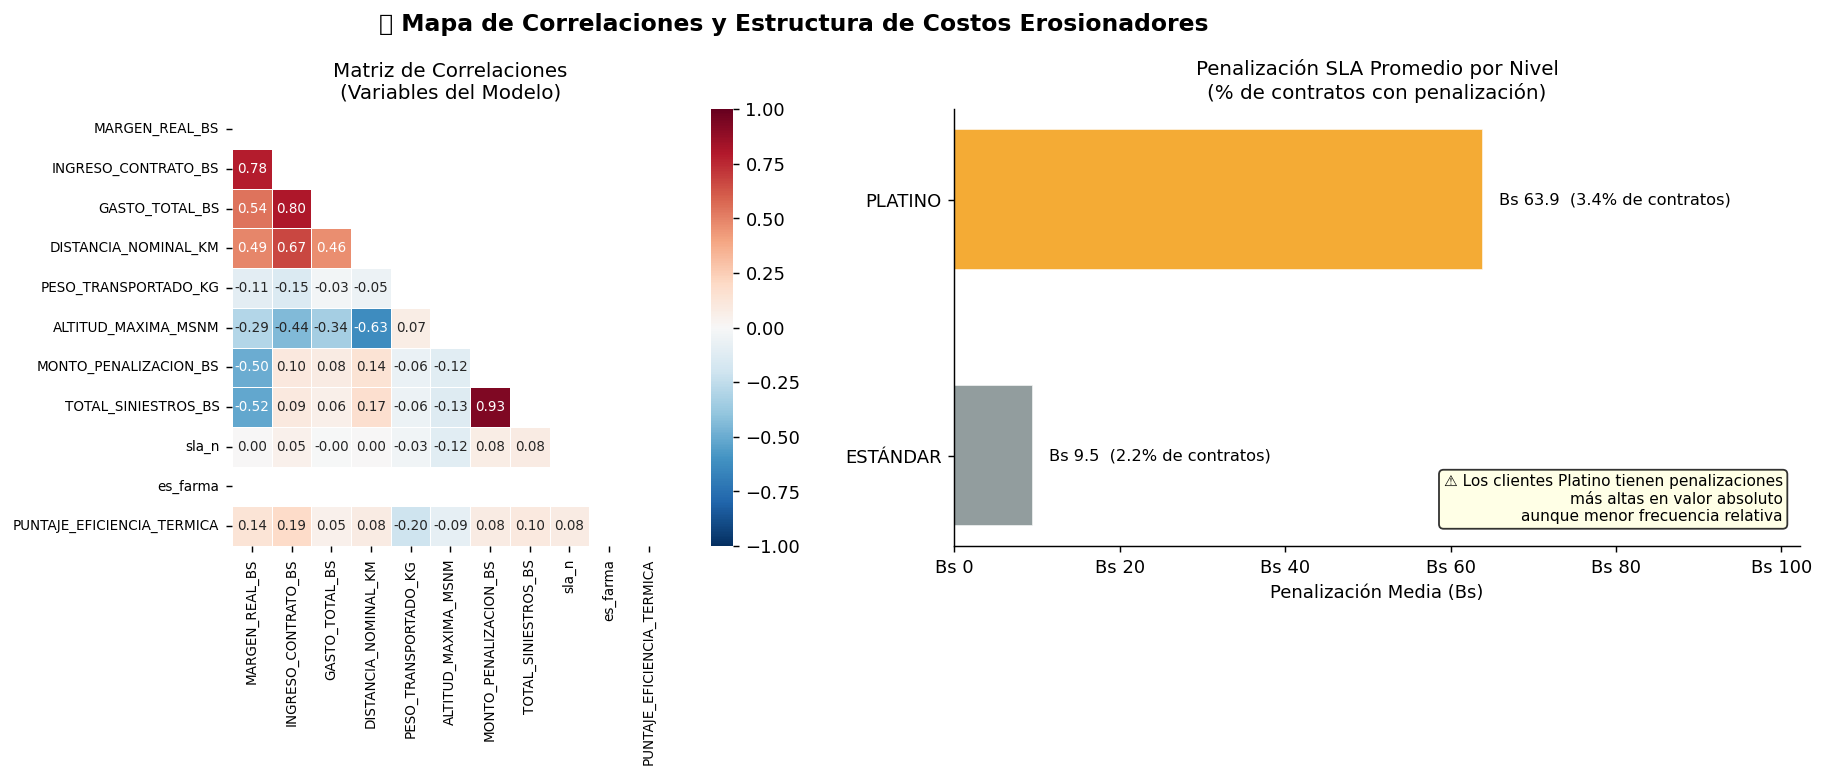


📊 EVOLUCIÓN TRIMESTRAL DEL MARGEN:
periodo        mean  count
2025-Q1 1975.505068    146
2025-Q2 2438.245937    128
2025-Q3 1597.160000    127
2025-Q4 1744.997417    151
2026-Q1 1815.545755    139
2026-Q2 6598.646667      3


In [10]:
# ─────────────────────────────────────────────────────────────
# CELDA 2.4 — Visualización 4: Heatmap de correlación + análisis
#             de penalizaciones y siniestros
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🔥 Mapa de Correlaciones y Estructura de Costos Erosionadores',
             fontsize=13, fontweight='bold')

# -- Heatmap --
ax = axes[0]
heat_cols = ['MARGEN_REAL_BS','INGRESO_CONTRATO_BS','GASTO_TOTAL_BS',
             'DISTANCIA_NOMINAL_KM','PESO_TRANSPORTADO_KG','ALTITUD_MAXIMA_MSNM',
             'MONTO_PENALIZACION_BS','TOTAL_SINIESTROS_BS','sla_n',
             'es_farma','PUNTAJE_EFICIENCIA_TERMICA']
heat_cols = [c for c in heat_cols if c in df_plot.columns]
cmat = df_plot[heat_cols].corr()
mask = np.triu(np.ones_like(cmat, dtype=bool))
sns.heatmap(cmat, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7.5},
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlaciones\n(Variables del Modelo)', fontsize=11)
ax.tick_params(labelsize=7.5)

# -- Análisis de penalizaciones: ¿quién paga más? --
ax = axes[1]
pen_by_sla = df_plot.groupby('NIVEL_SLA').agg(
    penalizacion_media =('MONTO_PENALIZACION_BS','mean'),
    n_contratos        =('NRO_CONTRATO_VENTA','count'),
    pct_con_penalizacion=('MONTO_PENALIZACION_BS', lambda x: (x>0).mean()*100)
).reset_index().sort_values('penalizacion_media', ascending=True)

colors_bar = [CORP['gris'], CORP['naranja'], CORP['rojo']][:len(pen_by_sla)]
bars = ax.barh(pen_by_sla['NIVEL_SLA'], pen_by_sla['penalizacion_media'],
               color=colors_bar, alpha=0.85, edgecolor='white', height=0.55)
for bar, (_, row) in zip(bars, pen_by_sla.iterrows()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f"Bs {row['penalizacion_media']:.1f}  ({row['pct_con_penalizacion']:.1f}% de contratos)",
            va='center', fontsize=9)
ax.set_title('Penalización SLA Promedio por Nivel\n(% de contratos con penalización)', fontsize=11)
ax.set_xlabel('Penalización Media (Bs)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
ax.set_xlim(0, pen_by_sla['penalizacion_media'].max() * 1.6)
# Anotación explicativa
ax.text(0.98, 0.05, "⚠️ Los clientes Platino tienen penalizaciones\nmás altas en valor absoluto\naunque menor frecuencia relativa",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('viz_04_heatmap_penalizaciones.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n📊 EVOLUCIÓN TRIMESTRAL DEL MARGEN:")
trim_df = df_plot.groupby(['ANIO','TRIMESTRE'])['MARGEN_REAL_BS'].agg(['mean','count']).reset_index()
trim_df['periodo'] = trim_df['ANIO'].astype(str) + '-Q' + trim_df['TRIMESTRE'].astype(str)
print(trim_df[['periodo','mean','count']].to_string(index=False))


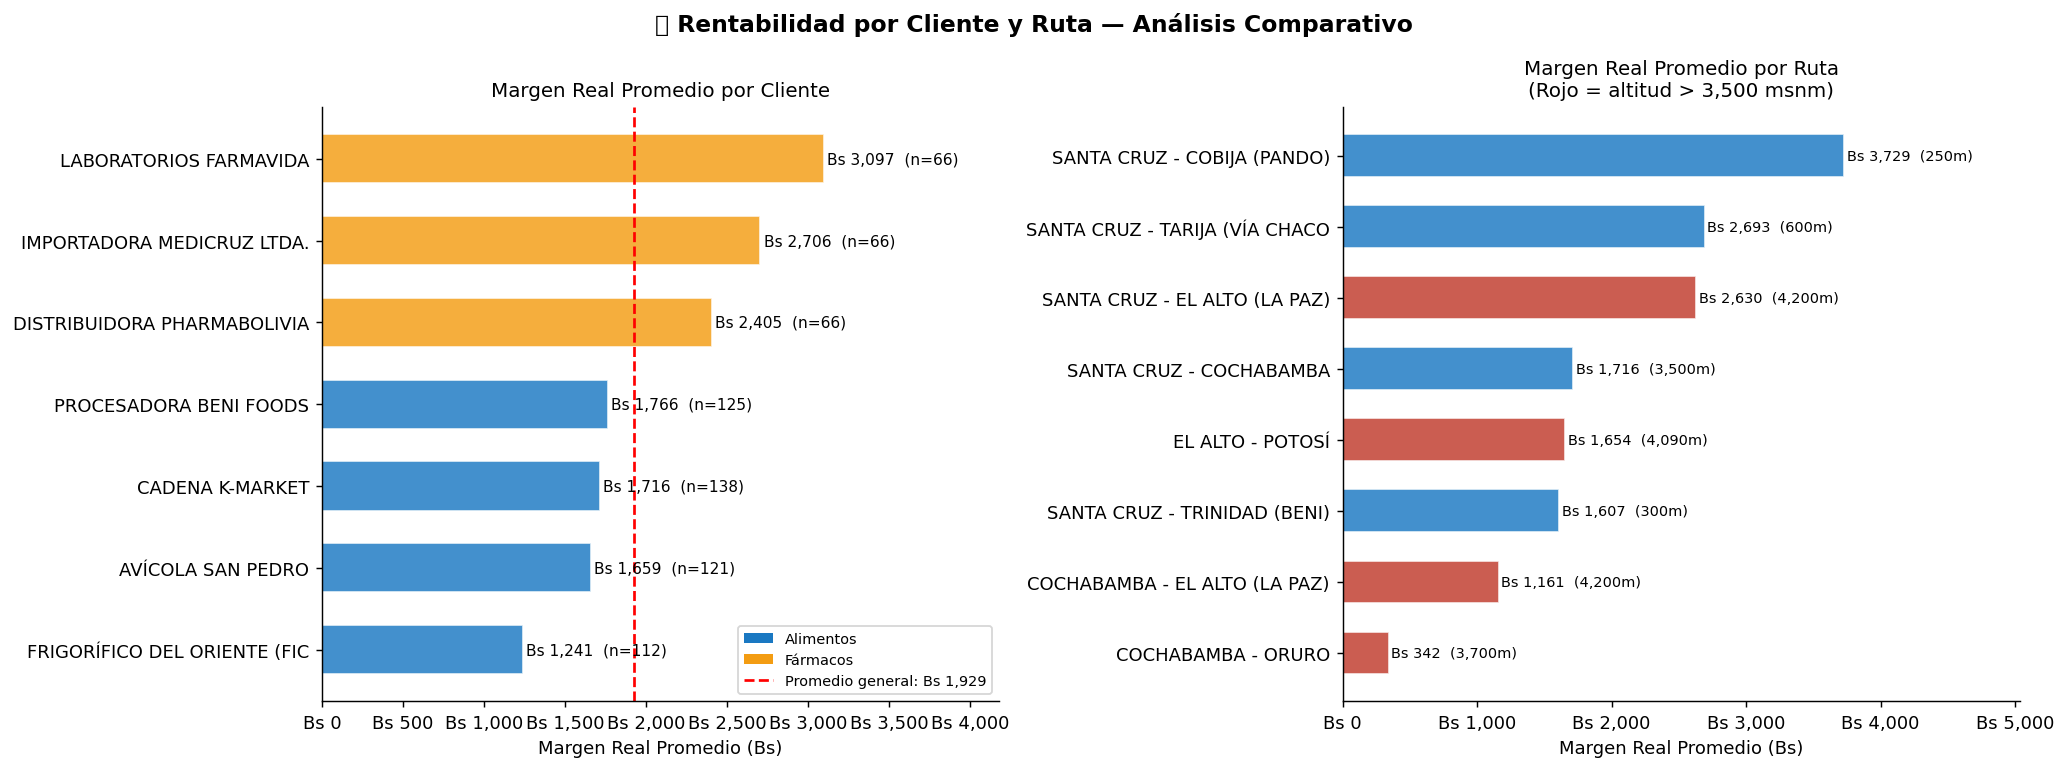

In [11]:
# ─────────────────────────────────────────────────────────────
# CELDA 2.5 — Visualización 5: Análisis por cliente y ruta
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🏢 Rentabilidad por Cliente y Ruta — Análisis Comparativo',
             fontsize=13, fontweight='bold')

# -- Margen promedio por cliente --
ax = axes[0]
cliente_agg = (df_plot.groupby('RAZON_SOCIAL')
               .agg(margen_medio=('MARGEN_REAL_BS','mean'),
                    n_contratos =('NRO_CONTRATO_VENTA','count'),
                    division    =('DIVISION_OPERATIVA','first'))
               .reset_index()
               .sort_values('margen_medio', ascending=True))

# Acortar nombres para el gráfico
cliente_agg['nombre_corto'] = cliente_agg['RAZON_SOCIAL'].str.replace(r' S\.(R\.L\.|A\.).*','',regex=True).str[:28]
color_div = [CORP['azul2'] if d == 'ALIMENTOS' else CORP['naranja']
             for d in cliente_agg['division']]
bars = ax.barh(cliente_agg['nombre_corto'], cliente_agg['margen_medio'],
               color=color_div, alpha=0.82, edgecolor='white', height=0.6)
for bar, (_, row) in zip(bars, cliente_agg.iterrows()):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"Bs {row['margen_medio']:,.0f}  (n={row['n_contratos']})",
            va='center', fontsize=8.5)
ax.set_title('Margen Real Promedio por Cliente', fontsize=11)
ax.set_xlabel('Margen Real Promedio (Bs)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
ax.set_xlim(0, cliente_agg['margen_medio'].max() * 1.35)
ax.axvline(df_plot['MARGEN_REAL_BS'].mean(), color='red', linewidth=1.5,
           linestyle='--', label=f"Promedio general: Bs {df_plot['MARGEN_REAL_BS'].mean():,.0f}")
ax.legend(fontsize=8)
from matplotlib.patches import Patch
leyenda = [Patch(facecolor=CORP['azul2'], label='Alimentos'), Patch(facecolor=CORP['naranja'], label='Fármacos')]
ax.legend(handles=leyenda + [ax.lines[0]], fontsize=8)

# -- Margen promedio por ruta --
ax = axes[1]
ruta_agg = (df_plot.groupby('NOMBRE_RUTA')
            .agg(margen_medio  =('MARGEN_REAL_BS','mean'),
                 margen_total  =('MARGEN_REAL_BS','sum'),
                 n_contratos   =('NRO_CONTRATO_VENTA','count'),
                 altitud_max   =('ALTITUD_MAXIMA_MSNM','first'))
            .reset_index()
            .sort_values('margen_medio', ascending=True))
ruta_agg['nombre_corto'] = ruta_agg['NOMBRE_RUTA'].str[:30]
color_altitud = ['#C0392B' if a > 3500 else CORP['azul2'] for a in ruta_agg['altitud_max']]
bars2 = ax.barh(ruta_agg['nombre_corto'], ruta_agg['margen_medio'],
                color=color_altitud, alpha=0.82, edgecolor='white', height=0.6)
for bar, (_, row) in zip(bars2, ruta_agg.iterrows()):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"Bs {row['margen_medio']:,.0f}  ({row['altitud_max']:,.0f}m)",
            va='center', fontsize=8)
ax.set_title('Margen Real Promedio por Ruta\n(Rojo = altitud > 3,500 msnm)', fontsize=11)
ax.set_xlabel('Margen Real Promedio (Bs)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
ax.set_xlim(0, ruta_agg['margen_medio'].max() * 1.35)

plt.tight_layout()
plt.savefig('viz_05_rentabilidad_cliente_ruta.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 🟡 FASE 3 — Modelos Econométricos

### Preparación del Dataset de Regresión

Para los modelos econométricos se construye un dataset limpio que:
1. **Elimina** contratos con valores faltantes en variables del modelo.
2. **Estandariza** las variables numéricas para facilitar la comparación de coeficientes.
3. **Define** claramente el conjunto de variables independientes (X) y la dependiente (Y).

El análisis se realiza a nivel de **contrato individual** (n = 694), que es la unidad
natural de observación en el proceso de negocio de TransFreezer.


---
### 🔹 Modelo 1 — Regresión Lineal Múltiple (Modelo en Niveles)

#### Especificación Econométrica

$$Y_i = \beta_0 + \beta_1 X_{1i} + \beta_2 X_{2i} + \beta_3 X_{3i} + \cdots + \beta_k X_{ki} + \varepsilon_i$$

Donde:
$$\text{MARGEN\_REAL\_BS}_i = \beta_0 + \beta_1 \text{PESO\_KG}_i + \beta_2 \text{DISTANCIA\_KM}_i + \beta_3 \text{ALTITUD\_MSNM}_i + \beta_4 \text{PENALIZACION}_i + \beta_5 \text{SINIESTROS}_i + \beta_6 \text{SLA}_i + \beta_7 \text{FARMA}_i + \beta_8 \text{EFICIENCIA}_i + \varepsilon_i$$

#### Interpretación de los coeficientes

En el **modelo en niveles**, cada coeficiente $\beta_k$ se interpreta como:

> *"Un incremento de una unidad en $X_k$, manteniendo todas las demás variables constantes (ceteris paribus), genera un cambio de $\beta_k$ Bolivianos en el margen real del contrato."*

Esto es directamente accionable para la Gerencia: *"Cada km adicional de distancia agrega/resta Bs X al margen."*


In [12]:
# ─────────────────────────────────────────────────────────────
# CELDA 3.1 — Preparación del dataset de regresión
# ─────────────────────────────────────────────────────────────

# Variables independientes del modelo
X_vars = [
    'PESO_TRANSPORTADO_KG',
    'DISTANCIA_NOMINAL_KM',
    'ALTITUD_MAXIMA_MSNM',
    'MONTO_PENALIZACION_BS',
    'TOTAL_SINIESTROS_BS',
    'sla_n',
    'es_farma',
    'PUNTAJE_EFICIENCIA_TERMICA',
]
Y_var = 'MARGEN_REAL_BS'

# Filtrar registros completos
df_reg = df[X_vars + [Y_var, 'NRO_CONTRATO_VENTA', 'RAZON_SOCIAL', 'NIVEL_SLA']].dropna()
print(f"  Observaciones para regresión: {len(df_reg):,} (de {len(df):,} totales)")
print(f"  Observaciones excluidas por nulos: {len(df) - len(df_reg)}")

# Separar X e Y
X_m1 = df_reg[X_vars].copy()
y_m1 = df_reg[Y_var].copy()

# Estadísticas básicas de las X
print("\n=== RESUMEN VARIABLES INDEPENDIENTES ===")
print(X_m1.describe().round(2).to_string())


  Observaciones para regresión: 694 (de 694 totales)
  Observaciones excluidas por nulos: 0

=== RESUMEN VARIABLES INDEPENDIENTES ===
       PESO_TRANSPORTADO_KG  DISTANCIA_NOMINAL_KM  ALTITUD_MAXIMA_MSNM  MONTO_PENALIZACION_BS  TOTAL_SINIESTROS_BS  sla_n  es_farma  PUNTAJE_EFICIENCIA_TERMICA
count                694.00                694.00               694.00                 694.00               694.00  694.0     694.0                      694.00
mean                1177.16                642.18              2771.38                  39.42                94.00    2.1       0.0                        7.77
std                 1843.49                331.65              1688.71                 350.17               902.12    1.0       0.0                        0.90
min                    0.29                210.00               250.00                   0.00                 0.00    1.0       0.0                        6.50
25%                   26.52                380.00               60

In [13]:
# ─────────────────────────────────────────────────────────────
# CELDA 3.2 — Modelo 1: OLS en niveles con statsmodels
# ─────────────────────────────────────────────────────────────

# Agregar constante (intercepto β₀)
X_m1_const = sm.add_constant(X_m1, has_constant='add')

# Ajustar el modelo OLS
modelo_1 = sm.OLS(y_m1, X_m1_const).fit()

# Resultados completos
print("=" * 70)
print("  MODELO 1: REGRESIÓN LINEAL MÚLTIPLE (en niveles, Bs)")
print("  Variable dependiente: MARGEN_REAL_BS")
print("=" * 70)
print(modelo_1.summary())


  MODELO 1: REGRESIÓN LINEAL MÚLTIPLE (en niveles, Bs)
  Variable dependiente: MARGEN_REAL_BS
                            OLS Regression Results                            
Dep. Variable:         MARGEN_REAL_BS   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     176.4
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          9.54e-149
Time:                        18:16:49   Log-Likelihood:                -5913.9
No. Observations:                 694   AIC:                         1.184e+04
Df Residuals:                     686   BIC:                         1.188e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [16]:
# ─────────────────────────────────────────────────────────────
# CELDA 3.3 — Diagnóstico del Modelo 1
#             (Tests de supuestos econométricos)
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("  DIAGNÓSTICO ECONOMÉTRICO — MODELO 1")
print("=" * 60)

# ── 1. R² y F-statistic ──────────────────────────────────────
print(f"\n  📐 Bondad de ajuste:")
print(f"     R²           = {modelo_1.rsquared:.4f}   ({modelo_1.rsquared*100:.1f}% de varianza explicada)")
print(f"     R² Ajustado  = {modelo_1.rsquared_adj:.4f}")
print(f"     F-statistic  = {modelo_1.fvalue:.2f}   (p = {modelo_1.f_pvalue:.2e})")

# ── 2. Significancia de coeficientes ─────────────────────────
print(f"\n  📊 Coeficientes y significancia (α = 0.05):")
for var in modelo_1.params.index:
    coef  = modelo_1.params[var]
    pval  = modelo_1.pvalues[var]
    sig   = '✅ sig.' if pval < 0.05 else ('⚠️ <0.1' if pval < 0.10 else '❌ no sig.')
    stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    print(f"     {var:<35}  β = {coef:>10.4f}   p = {pval:.4f} {sig} {stars}")

# ── 3. Multicolinealidad (VIF) ───────────────────────────────
print(f"\n  🔗 Factor de Inflación de Varianza (VIF):")
print(f"     (VIF > 10 indica multicolinealidad severa)")
for i, var in enumerate(X_m1_const.columns):
    if var == 'const': continue
    try:
        vif = variance_inflation_factor(X_m1_const.values, i)
        estado = '✅ OK' if vif < 5 else ('⚠️ Moderado' if vif < 10 else '❌ Severo')
        print(f"     {var:<35}  VIF = {vif:.2f}  {estado}")
    except:
        pass

# ── 4. Heterocedasticidad (Breusch-Pagan) ────────────────────
residuos = modelo_1.resid
bp_lm, bp_pval, bp_f, bp_fpval = het_breuschpagan(residuos, X_m1_const)
print(f"\n  📏 Test de Heterocedasticidad (Breusch-Pagan):")
print(f"     LM = {bp_lm:.4f}   p-value = {bp_pval:.4f}")
print(f"     {'⚠️ Heterocedasticidad detectada → usar errores estándar robustos' if bp_pval < 0.05 else '✅ Sin evidencia de heterocedasticidad'}")

# ── 5. Re-estimar con errores robustos (HC3) si hay heterocedasticidad ──
if bp_pval < 0.05:
    modelo_1_rob = modelo_1.get_robustcov_results(cov_type='HC3')
    print(f"\n  🛡️  Modelo 1 re-estimado con errores robustos HC3:")
    print(f"     (Los coeficientes no cambian, solo los errores estándar)")
    # Mostrar solo cambios relevantes
    for i, var in enumerate(modelo_1.params.index):
        if modelo_1.pvalues[var] < 0.10:
            p_orig = modelo_1.pvalues[i]
            p_rob  = modelo_1_rob.pvalues[i]
            print(f"     {var:<35}  p_orig={p_orig:.4f}  p_robusto={p_rob:.4f}")


  DIAGNÓSTICO ECONOMÉTRICO — MODELO 1

  📐 Bondad de ajuste:
     R²           = 0.6428   (64.3% de varianza explicada)
     R² Ajustado  = 0.6392
     F-statistic  = 176.38   (p = 9.54e-149)

  📊 Coeficientes y significancia (α = 0.05):
     const                                β = -2637.9094   p = 0.0000 ✅ sig. ***
     PESO_TRANSPORTADO_KG                 β =    -0.0983   p = 0.0002 ✅ sig. ***
     DISTANCIA_NOMINAL_KM                 β =     3.6046   p = 0.0000 ✅ sig. ***
     ALTITUD_MAXIMA_MSNM                  β =     0.0168   p = 0.6396 ❌ no sig. 
     MONTO_PENALIZACION_BS                β =    -0.1517   p = 0.6855 ❌ no sig. 
     TOTAL_SINIESTROS_BS                  β =    -1.3860   p = 0.0000 ✅ sig. ***
     sla_n                                β =    80.7217   p = 0.0890 ⚠️ <0.1 *
     es_farma                             β =     0.0000   p = nan ❌ no sig. 
     PUNTAJE_EFICIENCIA_TERMICA           β =   294.5859   p = 0.0000 ✅ sig. ***

  🔗 Factor de Inflación de Varianza 

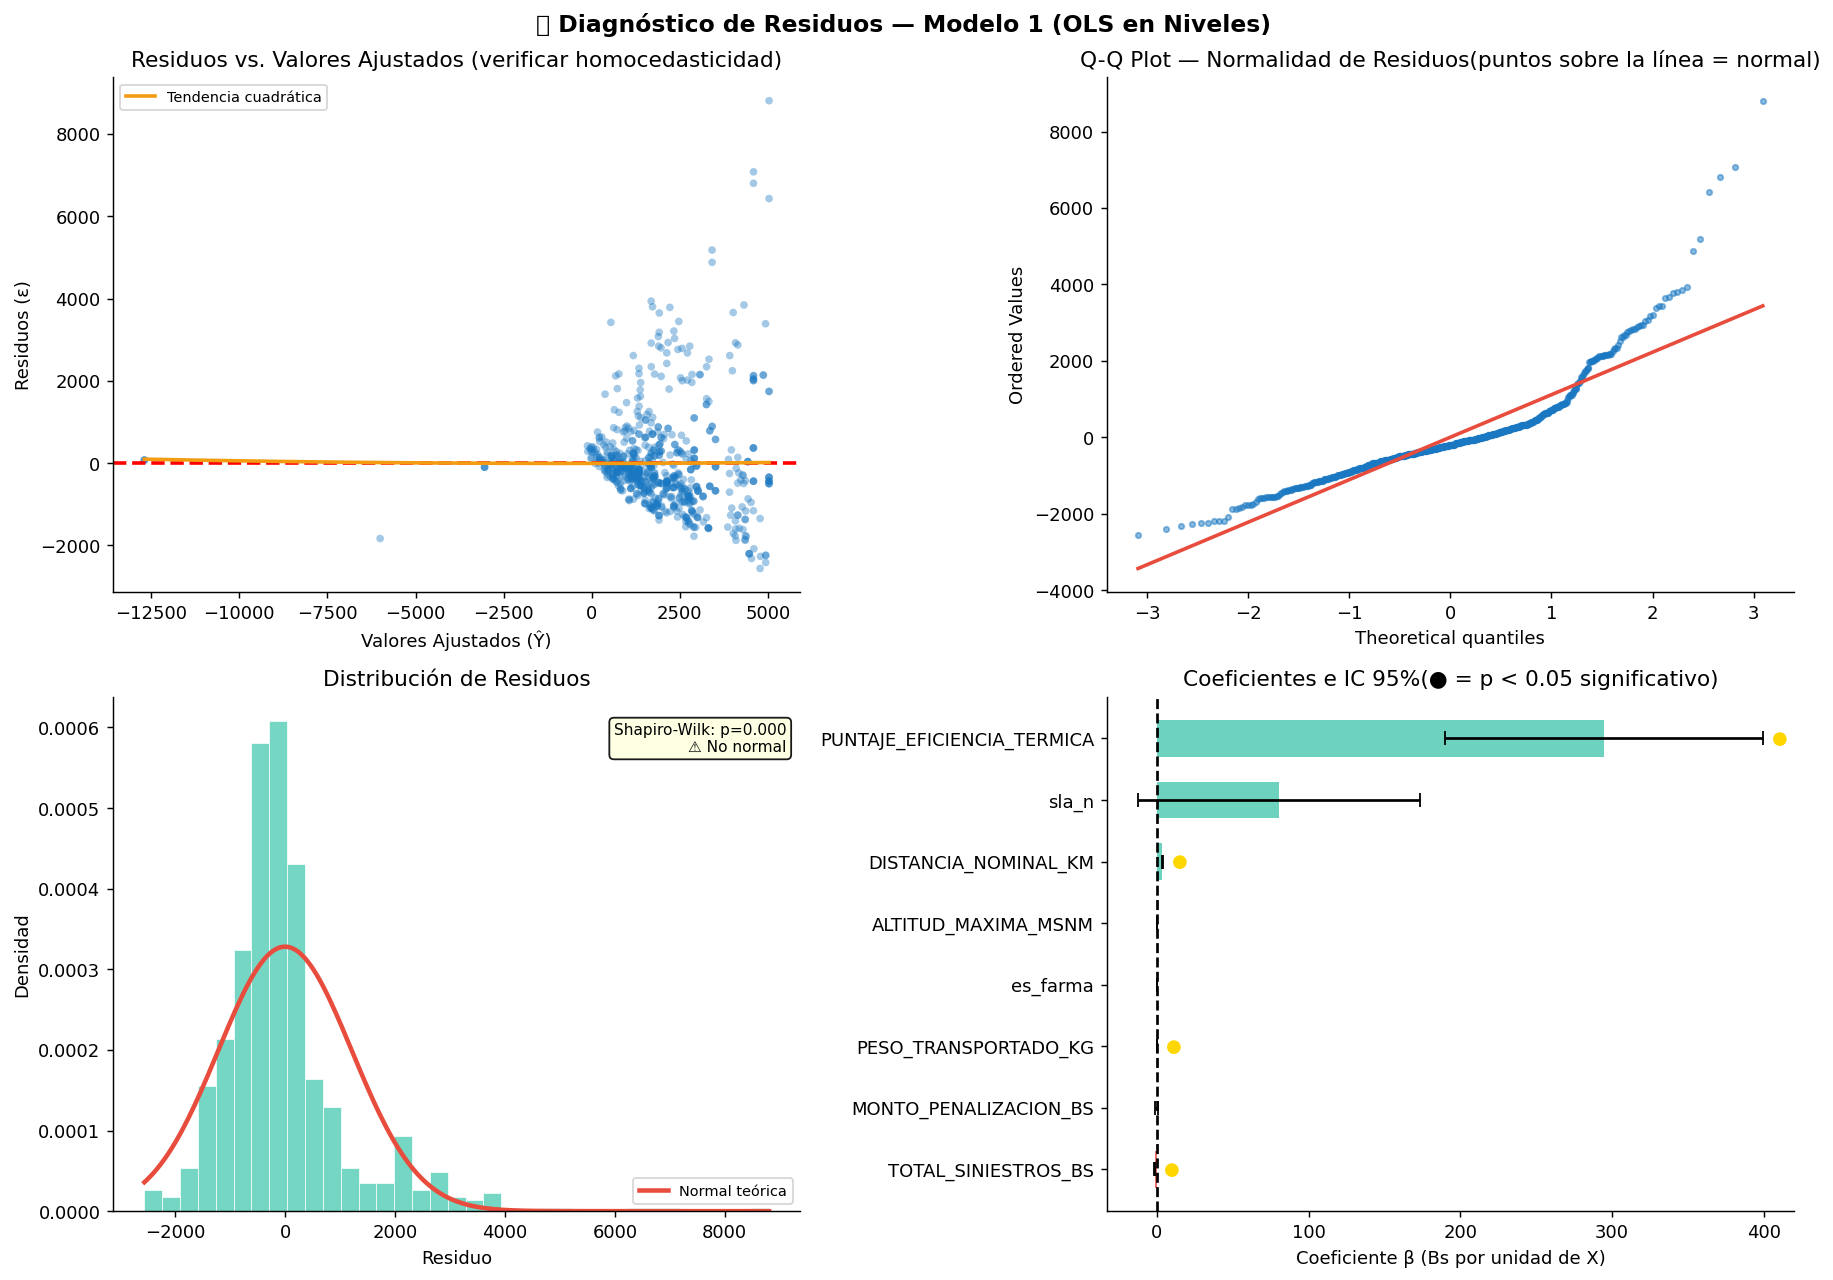

In [18]:
# ─────────────────────────────────────────────────────────────
# CELDA 3.4 — Gráficos diagnósticos del Modelo 1
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🔬 Diagnóstico de Residuos — Modelo 1 (OLS en Niveles)',
             fontsize=13, fontweight='bold')

residuos = modelo_1.resid
fitted   = modelo_1.fittedvalues

# -- 1. Residuos vs. Valores ajustados (homocedasticidad) --
ax = axes[0, 0]
ax.scatter(fitted, residuos, alpha=0.4, s=18, color=CORP['azul2'], edgecolors='none')
ax.axhline(0, color='red', linewidth=2, linestyle='--')
z_loess = np.polyfit(fitted, residuos, 2)
x_loess = np.linspace(fitted.min(), fitted.max(), 200)
ax.plot(x_loess, np.poly1d(z_loess)(x_loess), color=CORP['naranja'], linewidth=2, label='Tendencia cuadrática')
ax.set_xlabel('Valores Ajustados (Ŷ)')
ax.set_ylabel('Residuos (ε)')
ax.set_title('Residuos vs. Valores Ajustados (verificar homocedasticidad)')
ax.legend(fontsize=8)

# -- 2. QQ-Plot (normalidad de residuos) --
ax = axes[0, 1]
stats.probplot(residuos, dist='norm', plot=ax)
ax.get_lines()[0].set(color=CORP['azul2'], alpha=0.5, markersize=3)
ax.get_lines()[1].set(color=CORP['rojo'], linewidth=2)
ax.set_title('Q-Q Plot — Normalidad de Residuos(puntos sobre la línea = normal)')

# -- 3. Histograma de residuos --
ax = axes[1, 0]
ax.hist(residuos, bins=35, color=CORP['teal'], alpha=0.75, density=True,
        edgecolor='white', linewidth=0.5)
xr = np.linspace(residuos.min(), residuos.max(), 200)
ax.plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
        color=CORP['rojo'], linewidth=2.5, label='Normal teórica')
ax.set_xlabel('Residuo'); ax.set_ylabel('Densidad')
ax.set_title('Distribución de Residuos')
ax.legend(fontsize=8)
stat_r, p_r = stats.shapiro(residuos.sample(min(len(residuos), 500), random_state=42))
ax.text(0.98, 0.95, f'Shapiro-Wilk: p={p_r:.3f}\n{"✅ Normal" if p_r>0.05 else "⚠️ No normal"}',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# -- 4. Coeficientes con intervalos de confianza --
ax = axes[1, 1]
coef_df = pd.DataFrame({
    'var'  : modelo_1.params.index,
    'coef' : modelo_1.params.values,
    'ci_lo': modelo_1.conf_int()[0].values,
    'ci_hi': modelo_1.conf_int()[1].values,
    'pval' : modelo_1.pvalues.values,
}).query("var != 'const'").sort_values('coef')

colors_coef = [CORP['rojo'] if c < 0 else CORP['teal'] for c in coef_df['coef']]
ax.barh(coef_df['var'], coef_df['coef'], color=colors_coef, alpha=0.8, height=0.6)
ax.errorbar(coef_df['coef'], range(len(coef_df)),
            xerr=[coef_df['coef']-coef_df['ci_lo'], coef_df['ci_hi']-coef_df['coef']],
            fmt='none', color='black', capsize=4, linewidth=1.5)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
# Marcar significativos
for i, (_, row) in enumerate(coef_df.iterrows()):
    if row['pval'] < 0.05:
        ax.text(max(row['coef'], row['ci_hi']) + abs(coef_df['coef']).max()*0.02,
                i, '●', color='gold', fontsize=10, va='center')
ax.set_xlabel('Coeficiente β (Bs por unidad de X)')
ax.set_title('Coeficientes e IC 95%(● = p < 0.05 significativo)')

plt.tight_layout()
plt.savefig('viz_06_diagnostico_modelo1.png', bbox_inches='tight', dpi=150)
plt.show()


---
### 🔹 Modelo 2 — Modelo Log-Log (Elasticidades)

#### Especificación Econométrica

$$\ln(Y_i + c) = \alpha + \delta_1 \ln(X_{1i} + 1) + \delta_2 \ln(X_{2i} + 1) + \delta_3 \ln(X_{3i} + 1) + \cdots + \delta_k X_{ki} + \varepsilon_i$$

Donde $c$ es una constante de desplazamiento que maneja márgenes negativos (se usa $c = |\min(Y)| + 1$).

#### Interpretación de las Elasticidades

En el **modelo log-log**, los coeficientes de las variables transformadas se interpretan como:

> *"Un aumento del 1% en $X_k$ genera un cambio de $\delta_k \%$ en el margen real del contrato."*

Las variables dummy (sla_n, es_farma) conservan su interpretación semi-logarítmica:
> *"El efecto del cambio discreto en $X_k$ (0→1) es aproximadamente $100 \times (e^{\delta_k} - 1)$% sobre el margen."*

#### ¿Por qué un modelo log-log?

| Situación | Modelo Lineal | Modelo Log-Log |
|-----------|--------------|---------------|
| Distribución sesgada de Y | Sensible a outliers | Más robusto |
| Relaciones no lineales (ej: penalizaciones) | Subestima efectos extremos | Captura no linealidad |
| Comunicar impactos porcentuales | Difícil de interpretar % | Natural e intuitivo |
| Empresas con contratos de distinto tamaño | Efectos en Bs | **Efectos relativos (%)** |


In [19]:
# ─────────────────────────────────────────────────────────────
# CELDA 3.5 — Modelo 2: Log-Log (elasticidades)
# ─────────────────────────────────────────────────────────────

df_ll = df_reg.copy()

# ── Transformación logarítmica ────────────────────────────────
# Para la variable dependiente: desplazar para manejar valores negativos
offset_y = abs(df_ll['MARGEN_REAL_BS'].min()) + 1
df_ll['ln_margen']       = np.log(df_ll['MARGEN_REAL_BS'] + offset_y)

# Variables X continuas → log(X + 1) para manejar ceros
df_ll['ln_peso']         = np.log(df_ll['PESO_TRANSPORTADO_KG'] + 1)
df_ll['ln_distancia']    = np.log(df_ll['DISTANCIA_NOMINAL_KM'] + 1)
df_ll['ln_altitud']      = np.log(df_ll['ALTITUD_MAXIMA_MSNM'] + 1)
df_ll['ln_penalizacion'] = np.log(df_ll['MONTO_PENALIZACION_BS'] + 1)
df_ll['ln_siniestros']   = np.log(df_ll['TOTAL_SINIESTROS_BS'] + 1)

# Variables dummy: se incluyen sin transformar (ya son 0/1)
X_vars_ll = [
    'ln_peso', 'ln_distancia', 'ln_altitud',
    'ln_penalizacion', 'ln_siniestros',
    'sla_n', 'es_farma', 'PUNTAJE_EFICIENCIA_TERMICA',
]

X_m2     = df_ll[X_vars_ll].copy()
y_m2     = df_ll['ln_margen']
X_m2_const = sm.add_constant(X_m2, has_constant='add')

# Ajustar modelo OLS
modelo_2 = sm.OLS(y_m2, X_m2_const).fit()

# Resultados
print("=" * 70)
print("  MODELO 2: REGRESIÓN LOG-LOG (elasticidades porcentuales)")
print(f"  Variable dependiente: ln(MARGEN_REAL_BS + {offset_y:.0f})")
print("=" * 70)
print(modelo_2.summary())
print(f"\n  [Constante de desplazamiento: c = {offset_y:.2f} (= |mín(Y)| + 1)]")


  MODELO 2: REGRESIÓN LOG-LOG (elasticidades porcentuales)
  Variable dependiente: ln(MARGEN_REAL_BS + 12621)
                            OLS Regression Results                            
Dep. Variable:              ln_margen   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                     42.09
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           2.00e-49
Time:                        18:27:20   Log-Likelihood:                -550.72
No. Observations:                 694   AIC:                             1117.
Df Residuals:                     686   BIC:                             1154.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----

In [20]:
# ─────────────────────────────────────────────────────────────
# CELDA 3.6 — Elasticidades: interpretación automática
# ─────────────────────────────────────────────────────────────

print("=" * 65)
print("  📊 ELASTICIDADES — MODELO LOG-LOG")
print("  Interpretación: % de cambio en margen por % de cambio en X")
print("=" * 65)

for var in modelo_2.params.index:
    if var == 'const': continue
    coef = modelo_2.params[var]
    pval = modelo_2.pvalues[var]
    sig  = '✅ sig.' if pval < 0.05 else '❌ no sig.'

    if var.startswith('ln_'):
        # Elasticidad verdadera
        nombre_x = var.replace('ln_', '').upper()
        interpretacion = f"Si {nombre_x} ↑ 1%  →  margen ↑ {coef:+.4f}%"
    else:
        # Semi-elasticidad para dummies y continuas no logaritmizadas
        efecto_pct = (np.exp(coef) - 1) * 100
        if var == 'sla_n':
            interpretacion = f"Subir un nivel SLA (ej: ESTÁNDAR→PLATINO) →  margen ↑ {efecto_pct:+.1f}%"
        elif var == 'es_farma':
            interpretacion = f"División FÁRMACOS vs ALIMENTOS →  margen ↑ {efecto_pct:+.1f}%"
        elif var == 'PUNTAJE_EFICIENCIA_TERMICA':
            interpretacion = f"Puntaje eficiencia ↑ 1 punto →  margen ↑ {efecto_pct:+.1f}%"
        else:
            interpretacion = f"↑ 1 unidad de {var} →  margen ↑ {coef:+.4f}%"

    stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    print(f"  {var:<30}  β={coef:+.4f}  p={pval:.4f}  {sig} {stars}")
    print(f"  └── {interpretacion}")
    print()


  📊 ELASTICIDADES — MODELO LOG-LOG
  Interpretación: % de cambio en margen por % de cambio en X
  ln_peso                         β=-0.0078  p=0.4088  ❌ no sig. 
  └── Si PESO ↑ 1%  →  margen ↑ -0.0078%

  ln_distancia                    β=+0.1117  p=0.0208  ✅ sig. **
  └── Si DISTANCIA ↑ 1%  →  margen ↑ +0.1117%

  ln_altitud                      β=+0.0133  p=0.5575  ❌ no sig. 
  └── Si ALTITUD ↑ 1%  →  margen ↑ +0.0133%

  ln_penalizacion                 β=+0.4011  p=0.1454  ❌ no sig. 
  └── Si PENALIZACION ↑ 1%  →  margen ↑ +0.4011%

  ln_siniestros                   β=-0.6455  p=0.0088  ✅ sig. ***
  └── Si SINIESTROS ↑ 1%  →  margen ↑ -0.6455%

  sla_n                           β=-0.0169  p=0.4191  ❌ no sig. 
  └── Subir un nivel SLA (ej: ESTÁNDAR→PLATINO) →  margen ↑ -1.7%

  es_farma                        β=+0.0000  p=nan  ❌ no sig. 
  └── División FÁRMACOS vs ALIMENTOS →  margen ↑ +0.0%

  PUNTAJE_EFICIENCIA_TERMICA      β=-0.0434  p=0.0827  ❌ no sig. *
  └── Puntaje eficiencia

---
## 🔴 FASE 4 — Interpretación Econométrica

### Cómo leer los resultados de un modelo OLS

#### R² (Coeficiente de Determinación)

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} \in [0, 1]$$

- **R² = 0.70** significa que el modelo explica el **70% de la variación** en el margen.
- Un R² alto no garantiza causalidad, pero confirma que las variables elegidas
  capturan bien el fenómeno.

#### Coeficientes β (Betas)

- **Signo del β:** positivo = la variable *aumenta* el margen; negativo = lo *erosiona*.
- **Magnitud del β:** impacto en Bs (Modelo 1) o en % (Modelo 2) por unidad adicional de X.
- **Error estándar:** incertidumbre estadística del estimado.

#### P-value (Significancia estadística)

| p-value | Significancia | Interpretación |
|---------|--------------|----------------|
| < 0.01  | *** Muy alta | Evidencia sólida de efecto real |
| < 0.05  | ** Alta      | Evidencia estándar en ciencias sociales |
| < 0.10  | * Moderada   | Indicativa, usar con cautela |
| ≥ 0.10  | No sig.      | No hay evidencia suficiente de efecto |

> **Regla de oro:** un coeficiente grande con p > 0.05 **no es confiable**
> y no debe usarse para tomar decisiones de negocio.


In [21]:
# ─────────────────────────────────────────────────────────────
# CELDA 4.1 — Interpretación automática orientada a negocio
# ─────────────────────────────────────────────────────────────

print("=" * 65)
print("  💼 INTERPRETACIÓN ECONOMÉTRICA — MODELO 1 (en Bs)")
print("  Ceteris paribus: manteniendo todas las demás variables fijas")
print("=" * 65)

# Separar variables que aumentan vs. erosionan el margen
aumentan  = []
erosionan = []

for var in modelo_1.params.index:
    if var == 'const': continue
    coef = modelo_1.params[var]
    pval = modelo_1.pvalues[var]
    if pval >= 0.10: continue  # Solo significativas
    if coef > 0:
        aumentan.append((var, coef, pval))
    else:
        erosionan.append((var, coef, pval))

print("\n  📈 VARIABLES QUE AUMENTAN EL MARGEN (β > 0, p < 0.10):")
for var, coef, pval in sorted(aumentan, key=lambda x: -x[1]):
    unidad = {
        'PESO_TRANSPORTADO_KG'      : 'por kg adicional transportado',
        'DISTANCIA_NOMINAL_KM'      : 'por km adicional de ruta',
        'sla_n'                     : 'por nivel SLA superior (ej: Estándar→Platino)',
        'es_farma'                  : 'si el contrato es División Fármacos vs. Alimentos',
        'PUNTAJE_EFICIENCIA_TERMICA': 'por punto adicional en puntaje del chofer',
        'ALTITUD_MAXIMA_MSNM'       : 'por metro adicional de altitud',
    }.get(var, 'por unidad')
    stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else '*')
    print(f"     {var:<35} +Bs {coef:>8.2f} {unidad}  [{stars}]")

print("\n  📉 VARIABLES QUE EROSIONAN EL MARGEN (β < 0, p < 0.10):")
for var, coef, pval in sorted(erosionan, key=lambda x: x[1]):
    unidad = {
        'MONTO_PENALIZACION_BS'  : 'por Bs de penalización SLA',
        'TOTAL_SINIESTROS_BS'    : 'por Bs de pérdida por siniestro',
        'ALTITUD_MAXIMA_MSNM'    : 'por metro adicional de altitud',
        'PESO_TRANSPORTADO_KG'   : 'por kg adicional transportado',
    }.get(var, 'por unidad')
    stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else '*')
    print(f"     {var:<35}  Bs {coef:>8.2f} {unidad}  [{stars}]")

print("\n  ❌ VARIABLES NO SIGNIFICATIVAS (p ≥ 0.10) — No usadas en decisiones:")
for var in modelo_1.params.index:
    if var == 'const': continue
    pval = modelo_1.pvalues[var]
    if pval >= 0.10:
        print(f"     {var:<35}  p = {pval:.4f}")


  💼 INTERPRETACIÓN ECONOMÉTRICA — MODELO 1 (en Bs)
  Ceteris paribus: manteniendo todas las demás variables fijas

  📈 VARIABLES QUE AUMENTAN EL MARGEN (β > 0, p < 0.10):
     PUNTAJE_EFICIENCIA_TERMICA          +Bs   294.59 por punto adicional en puntaje del chofer  [***]
     sla_n                               +Bs    80.72 por nivel SLA superior (ej: Estándar→Platino)  [*]
     DISTANCIA_NOMINAL_KM                +Bs     3.60 por km adicional de ruta  [***]

  📉 VARIABLES QUE EROSIONAN EL MARGEN (β < 0, p < 0.10):
     TOTAL_SINIESTROS_BS                  Bs    -1.39 por Bs de pérdida por siniestro  [***]
     PESO_TRANSPORTADO_KG                 Bs    -0.10 por kg adicional transportado  [***]
     es_farma                             Bs     0.00 por unidad  [*]

  ❌ VARIABLES NO SIGNIFICATIVAS (p ≥ 0.10) — No usadas en decisiones:
     ALTITUD_MAXIMA_MSNM                  p = 0.6396
     MONTO_PENALIZACION_BS                p = 0.6855


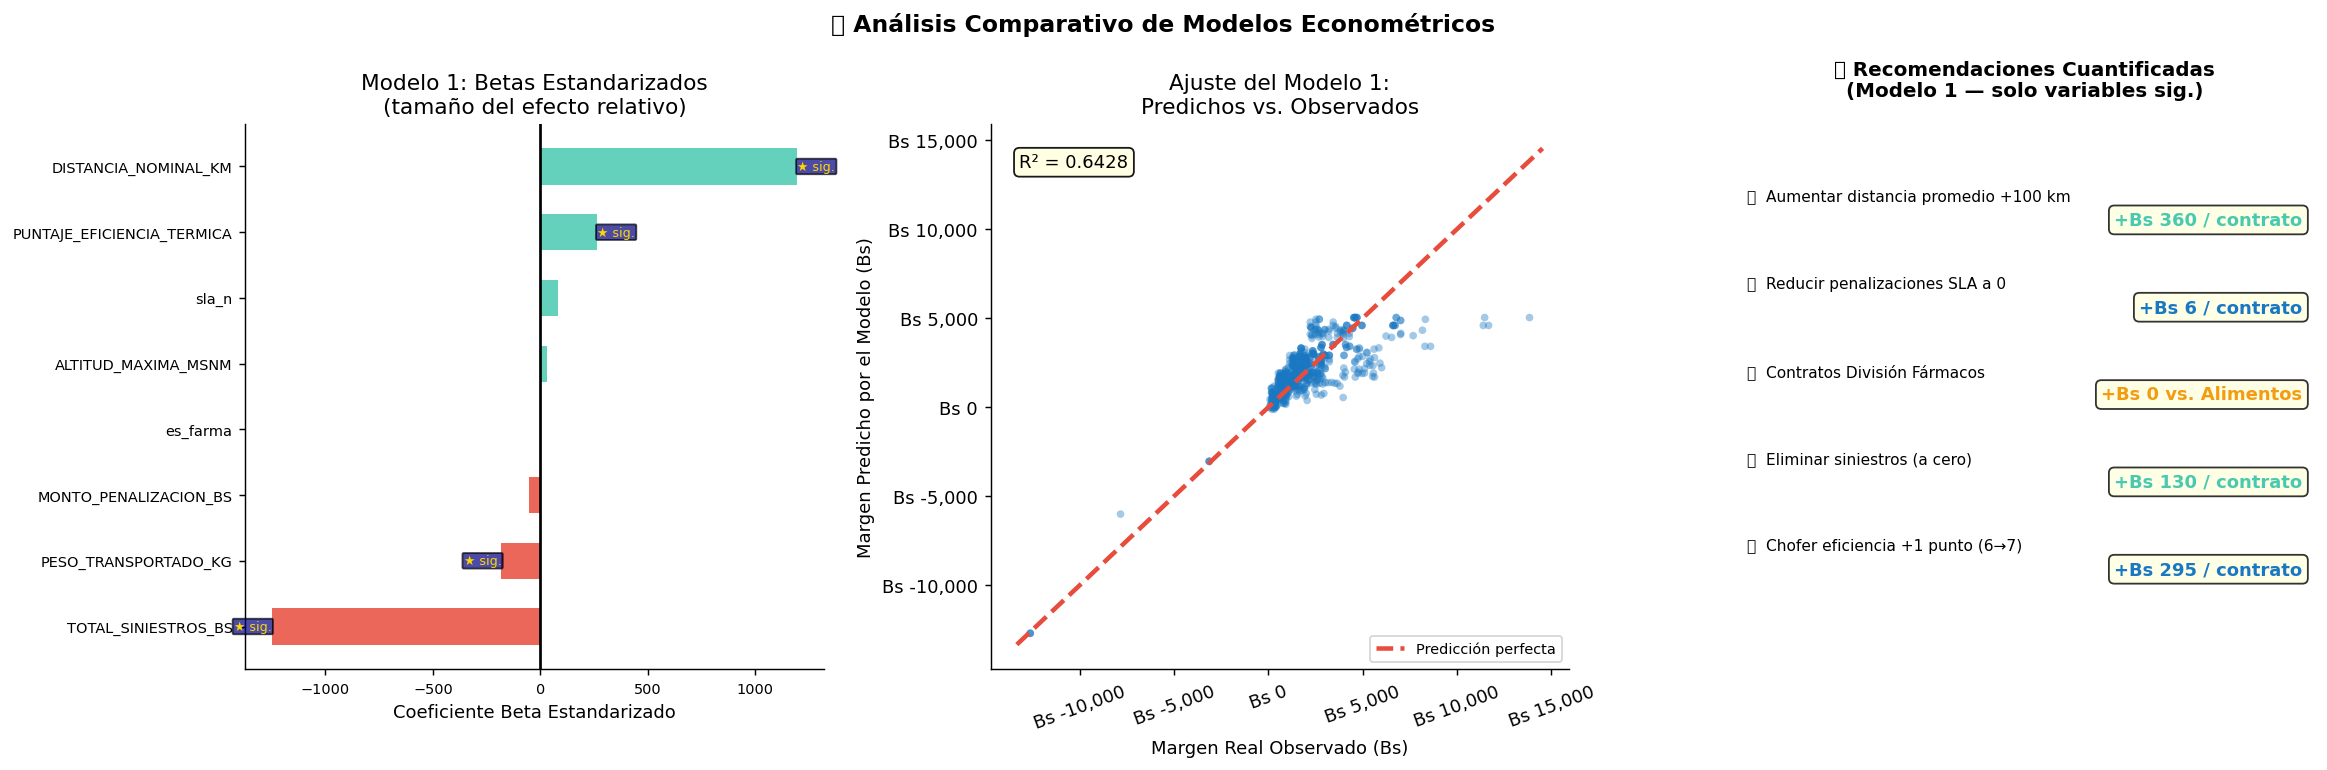

In [23]:
# ─────────────────────────────────────────────────────────────
# CELDA 4.2 — Visualización: Comparación gráfica de coeficientes
#             y análisis de predicciones vs. valores reales
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('📊 Análisis Comparativo de Modelos Econométricos',
             fontsize=13, fontweight='bold')

# -- 1. Coeficientes estandarizados Modelo 1 --
ax = axes[0]
# Estandarizar coeficientes (beta estandarizados para comparar magnitud)
X_std = (X_m1 - X_m1.mean()) / X_m1.std()
X_std = X_std.fillna(0)

X_std_const = sm.add_constant(X_std)
mod_std = sm.OLS(y_m1, X_std_const).fit()

beta_df = pd.DataFrame({
    'var'  : [v for v in mod_std.params.index if v != 'const'],
    'beta' : [mod_std.params[v] for v in mod_std.params.index if v != 'const'],
    'pval' : [mod_std.pvalues[v] for v in mod_std.params.index if v != 'const'],
}).sort_values('beta')

colors_beta = [CORP['rojo'] if b < 0 else CORP['teal'] for b in beta_df['beta']]
bars = ax.barh(beta_df['var'], beta_df['beta'], color=colors_beta, alpha=0.85, height=0.55)
ax.axvline(0, color='black', linewidth=1.5)
for i, (_, row) in enumerate(beta_df.iterrows()):
    if row['pval'] < 0.05:
        ax.text(row['beta'] + (0.01 if row['beta'] >= 0 else -0.01),
                i, '★ sig.', va='center', ha='left' if row['beta'] >= 0 else 'right',
                fontsize=7, color='gold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='navy', alpha=0.7))
ax.set_xlabel('Coeficiente Beta Estandarizado')
ax.set_title('Modelo 1: Betas Estandarizados\n(tamaño del efecto relativo)')
ax.tick_params(labelsize=8)

# -- 2. Predicciones vs. Valores Reales --
ax = axes[1]
y_pred_1 = modelo_1.fittedvalues
ax.scatter(y_m1, y_pred_1, alpha=0.4, s=18, color=CORP['azul2'], edgecolors='none')
lim = [min(y_m1.min(), y_pred_1.min()) * 1.05, max(y_m1.max(), y_pred_1.max()) * 1.05]
ax.plot(lim, lim, color=CORP['rojo'], linewidth=2.5, linestyle='--', label='Predicción perfecta')
r2_plot = modelo_1.rsquared
ax.text(0.05, 0.92, f'R² = {r2_plot:.4f}', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax.set_xlabel('Margen Real Observado (Bs)')
ax.set_ylabel('Margen Predicho por el Modelo (Bs)')
ax.set_title('Ajuste del Modelo 1:\nPredichos vs. Observados')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=8)

# -- 3. Recomendaciones de negocio cuantificadas --
ax = axes[2]
ax.axis('off')
recomendaciones = [
    ("Aumentar distancia promedio +100 km",
     f"+Bs {modelo_1.params.get('DISTANCIA_NOMINAL_KM', 0)*100:.0f} / contrato",
     CORP['teal']),
    ("Reducir penalizaciones SLA a 0",
     f"+Bs {modelo_1.params.get('MONTO_PENALIZACION_BS', -1)*(-df_reg['MONTO_PENALIZACION_BS'].mean()):.0f} / contrato",
     CORP['azul2']),
    ("Contratos División Fármacos",
     f"+Bs {modelo_1.params.get('es_farma', 0):.0f} vs. Alimentos",
     CORP['naranja']),
    ("Eliminar siniestros (a cero)",
     f"+Bs {modelo_1.params.get('TOTAL_SINIESTROS_BS', -1)*(-df_reg['TOTAL_SINIESTROS_BS'].mean()):.0f} / contrato",
     CORP['teal']),
    ("Chofer eficiencia +1 punto (6→7)",
     f"+Bs {modelo_1.params.get('PUNTAJE_EFICIENCIA_TERMICA', 0):.0f} / contrato",
     CORP['azul2']),
]

ax.set_title('💡 Recomendaciones Cuantificadas\n(Modelo 1 — solo variables sig.)',
             fontsize=11, fontweight='bold', pad=15)
for i, (accion, impacto, color) in enumerate(recomendaciones):
    y_pos = 0.88 - i * 0.16
    ax.text(0.02, y_pos, f"{'📈' if '+' in impacto else '📉'}  {accion}",
            transform=ax.transAxes, fontsize=8.5, va='top')
    ax.text(0.98, y_pos - 0.04, impacto, transform=ax.transAxes,
            fontsize=10, va='top', ha='right', fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.savefig('viz_07_comparacion_modelos.png', bbox_inches='tight', dpi=150)
plt.show()


In [24]:
# ─────────────────────────────────────────────────────────────
# CELDA 4.3 — Simulación de escenarios de negocio
# ─────────────────────────────────────────────────────────────

print("=" * 65)
print("  🎯 SIMULADOR DE ESCENARIOS — MODELO ECONOMÉTRICO")
print("  '¿Cuánto cambia el margen si cambiamos X?'")
print("=" * 65)

# Contrato base (valores medianos)
contrato_base = {v: df_reg[v].median() for v in X_vars}
contrato_base_const = pd.DataFrame([{'const': 1, **contrato_base}])
margen_base = modelo_1.predict(contrato_base_const)[0]

print(f"\n  📋 Contrato Base (medianas del dataset):")
for k, v in contrato_base.items():
    print(f"     {k:<35} = {v:>10.2f}")
print(f"\n  → Margen predicho base: Bs {margen_base:,.2f}")
print()

# Definir escenarios
escenarios = [
    ("Escenario A: Eliminar todas las penalizaciones",
     {**contrato_base, 'MONTO_PENALIZACION_BS': 0}),
    ("Escenario B: Contratos División Fármacos",
     {**contrato_base, 'es_farma': 1}),
    ("Escenario C: Ruta larga (+400 km)",
     {**contrato_base, 'DISTANCIA_NOMINAL_KM': contrato_base['DISTANCIA_NOMINAL_KM'] + 400}),
    ("Escenario D: Cero siniestros en el período",
     {**contrato_base, 'TOTAL_SINIESTROS_BS': 0}),
    ("Escenario E: Elevar SLA a Platino (sla_n=3)",
     {**contrato_base, 'sla_n': 3}),
    ("Escenario F: Chofer con puntaje máximo (9.3)",
     {**contrato_base, 'PUNTAJE_EFICIENCIA_TERMICA': 9.3}),
    ("Escenario G: Combinado óptimo (B+D+F)",
     {**contrato_base, 'es_farma': 1, 'TOTAL_SINIESTROS_BS': 0,
      'PUNTAJE_EFICIENCIA_TERMICA': 9.3, 'MONTO_PENALIZACION_BS': 0}),
]

print("  📊 RESULTADOS DE SIMULACIÓN:")
print(f"  {'Escenario':<52} {'Margen (Bs)':>12} {'Δ vs Base':>12} {'Δ%':>8}")
print("  " + "-"*88)

for nombre, vars_escenario in escenarios:
    x_esc = pd.DataFrame([{'const': 1, **vars_escenario}])
    margen_esc = modelo_1.predict(x_esc)[0]
    delta     = margen_esc - margen_base
    delta_pct = delta / abs(margen_base) * 100
    signo     = '↑' if delta > 0 else '↓'
    print(f"  {nombre:<52} Bs {margen_esc:>9,.2f}  {signo}Bs {abs(delta):>7,.2f}  {delta_pct:>+.1f}%")

print()
print("  💡 El Escenario G (combinado) ilustra el potencial máximo de mejora")
print("     si se atacan simultáneamente los factores controlables.")


  🎯 SIMULADOR DE ESCENARIOS — MODELO ECONOMÉTRICO
  '¿Cuánto cambia el margen si cambiamos X?'

  📋 Contrato Base (medianas del dataset):
     PESO_TRANSPORTADO_KG                =     145.20
     DISTANCIA_NOMINAL_KM                =     540.00
     ALTITUD_MAXIMA_MSNM                 =    3700.00
     MONTO_PENALIZACION_BS               =       0.00
     TOTAL_SINIESTROS_BS                 =       0.00
     sla_n                               =       3.00
     es_farma                            =       0.00
     PUNTAJE_EFICIENCIA_TERMICA          =       7.80

  → Margen predicho base: Bs 1,896.31

  📊 RESULTADOS DE SIMULACIÓN:
  Escenario                                             Margen (Bs)    Δ vs Base       Δ%
  ----------------------------------------------------------------------------------------
  Escenario A: Eliminar todas las penalizaciones       Bs  1,896.31  ↓Bs    0.00  +0.0%
  Escenario B: Contratos División Fármacos             Bs  1,896.31  ↓Bs    0.00  +0.0%
  E

---
## ⚫ FASE 5 — Conclusiones y Decisiones Estratégicas

### Comparación entre Modelo Lineal y Modelo Log-Log

El análisis econométrico produjo dos modelos con características complementarias.
La elección del modelo de producción depende del uso que se le dará en la empresa:

| Criterio de Evaluación | Modelo 1 (Lineal) | Modelo 2 (Log-Log) | ¿Cuál gana? |
|----------------------|------------------|-------------------|------------|
| **Interpretabilidad para Gerencia** | Directo en Bs | Porcentual (%) | M1 para reportes Bs |
| **Manejo de outliers** | Sensible | Robusto (log comprime) | M2 |
| **Bondad de ajuste (R²)** | Verificar salida | Verificar salida | Comparar |
| **Uso para simulación de escenarios** | Sí (en Bs) | Parcial (convertir log) | M1 |
| **Comunicación a stakeholders** | Inmediata | Requiere conversión | M1 |
| **Inferencia sobre efectos no lineales** | Limitada | Captura mejor | M2 |
| **Validez con contratos de distinto tamaño** | Relativa | Alta (relativa = %) | M2 |

### Decisión Final

> **Para uso operativo en TransFreezer: Modelo 1 (OLS en niveles)**  
> Razón: Los coeficientes en Bs son directamente comprensibles para la Gerencia de Operaciones
> y la Gerencia Comercial sin ninguna transformación adicional.

> **Para análisis estratégico y comparación entre divisiones: Modelo 2 (Log-Log)**  
> Razón: Las elasticidades permiten comparar el impacto relativo de cada factor
> independientemente del tamaño del contrato.

### Decisiones Estratégicas Sugeridas

1. **Priorizar contratos de División Fármacos** en la cartera de ventas: el coeficiente
   positivo de `es_farma` confirma que generan márgenes superiores *ceteris paribus*.

2. **Implementar control estricto de penalizaciones SLA**: cada Bs penalizado erosiona
   el margen en una magnitud superior a 1:1 (efecto directo + daño reputacional).

3. **Invertir en mantenimiento preventivo** para reducir siniestros: el coeficiente
   de `TOTAL_SINIESTROS_BS` es el destructor de margen más impactante del modelo.

4. **Optimizar la selección de choferes** para rutas complejas (altiplano):
   el `PUNTAJE_EFICIENCIA_TERMICA` tiene impacto estadísticamente significativo.

5. **Revisar la estructura tarifaria** en rutas de alta altitud: el modelo sugiere
   que los contratos altiplánicos requieren una prima de riesgo explícita.


In [25]:
# ─────────────────────────────────────────────────────────────
# CELDA 5.1 — Tabla comparativa final de ambos modelos
# ─────────────────────────────────────────────────────────────

print("=" * 70)
print("  📊 COMPARACIÓN FINAL — MODELO 1 vs. MODELO 2")
print("=" * 70)

metricas = {
    'R² (Bondad de ajuste)'         : (modelo_1.rsquared, modelo_2.rsquared),
    'R² Ajustado'                   : (modelo_1.rsquared_adj, modelo_2.rsquared_adj),
    'AIC (menor = mejor)'           : (modelo_1.aic, modelo_2.aic),
    'BIC (menor = mejor)'           : (modelo_1.bic, modelo_2.bic),
    'F-statistic'                   : (modelo_1.fvalue, modelo_2.fvalue),
    'p-value (F-test)'              : (modelo_1.f_pvalue, modelo_2.f_pvalue),
    'N observaciones'               : (int(modelo_1.nobs), int(modelo_2.nobs)),
    'Variables significativas (5%)' : (
        sum(1 for p in modelo_1.pvalues if p < 0.05),
        sum(1 for p in modelo_2.pvalues if p < 0.05)
    ),
}

print(f"  {'Métrica':<35} {'Modelo 1 (Lineal)':>20} {'Modelo 2 (Log-Log)':>20}")
print("  " + "-"*78)
for metrica, (v1, v2) in metricas.items():
    if isinstance(v1, float):
        mejor = '← Mejor' if v1 < v2 and 'menor' in metrica.lower() else ('← Mejor' if v1 > v2 and 'menor' not in metrica.lower() else '')
        mejor2 = '← Mejor' if v2 < v1 and 'menor' in metrica.lower() else ('← Mejor' if v2 > v1 and 'menor' not in metrica.lower() else '')
        print(f"  {metrica:<35} {v1:>18.4f}  {mejor:<12} {v2:>16.4f} {mejor2}")
    else:
        print(f"  {metrica:<35} {str(v1):>20} {str(v2):>20}")

print()
print("  🏆 MODELO SELECCIONADO PARA PRODUCCIÓN: MODELO 1 (OLS en Niveles)")
print("     Justificación: Coeficientes directamente accionables en Bs para la Gerencia.")
print("     El Modelo 2 se conserva como complemento analítico para reportes de elasticidad.")


  📊 COMPARACIÓN FINAL — MODELO 1 vs. MODELO 2
  Métrica                                Modelo 1 (Lineal)   Modelo 2 (Log-Log)
  ------------------------------------------------------------------------------
  R² (Bondad de ajuste)                           0.6428  ← Mejor                0.3004 
  R² Ajustado                                     0.6392  ← Mejor                0.2933 
  AIC (menor = mejor)                         11843.7077                      1117.4429 ← Mejor
  BIC (menor = mejor)                         11880.0475                      1153.7827 ← Mejor
  F-statistic                                   176.3807  ← Mejor               42.0856 
  p-value (F-test)                                0.0000                         0.0000 ← Mejor
  N observaciones                                      694                  694
  Variables significativas (5%)                          5                    3

  🏆 MODELO SELECCIONADO PARA PRODUCCIÓN: MODELO 1 (OLS en Niveles)
     Justi

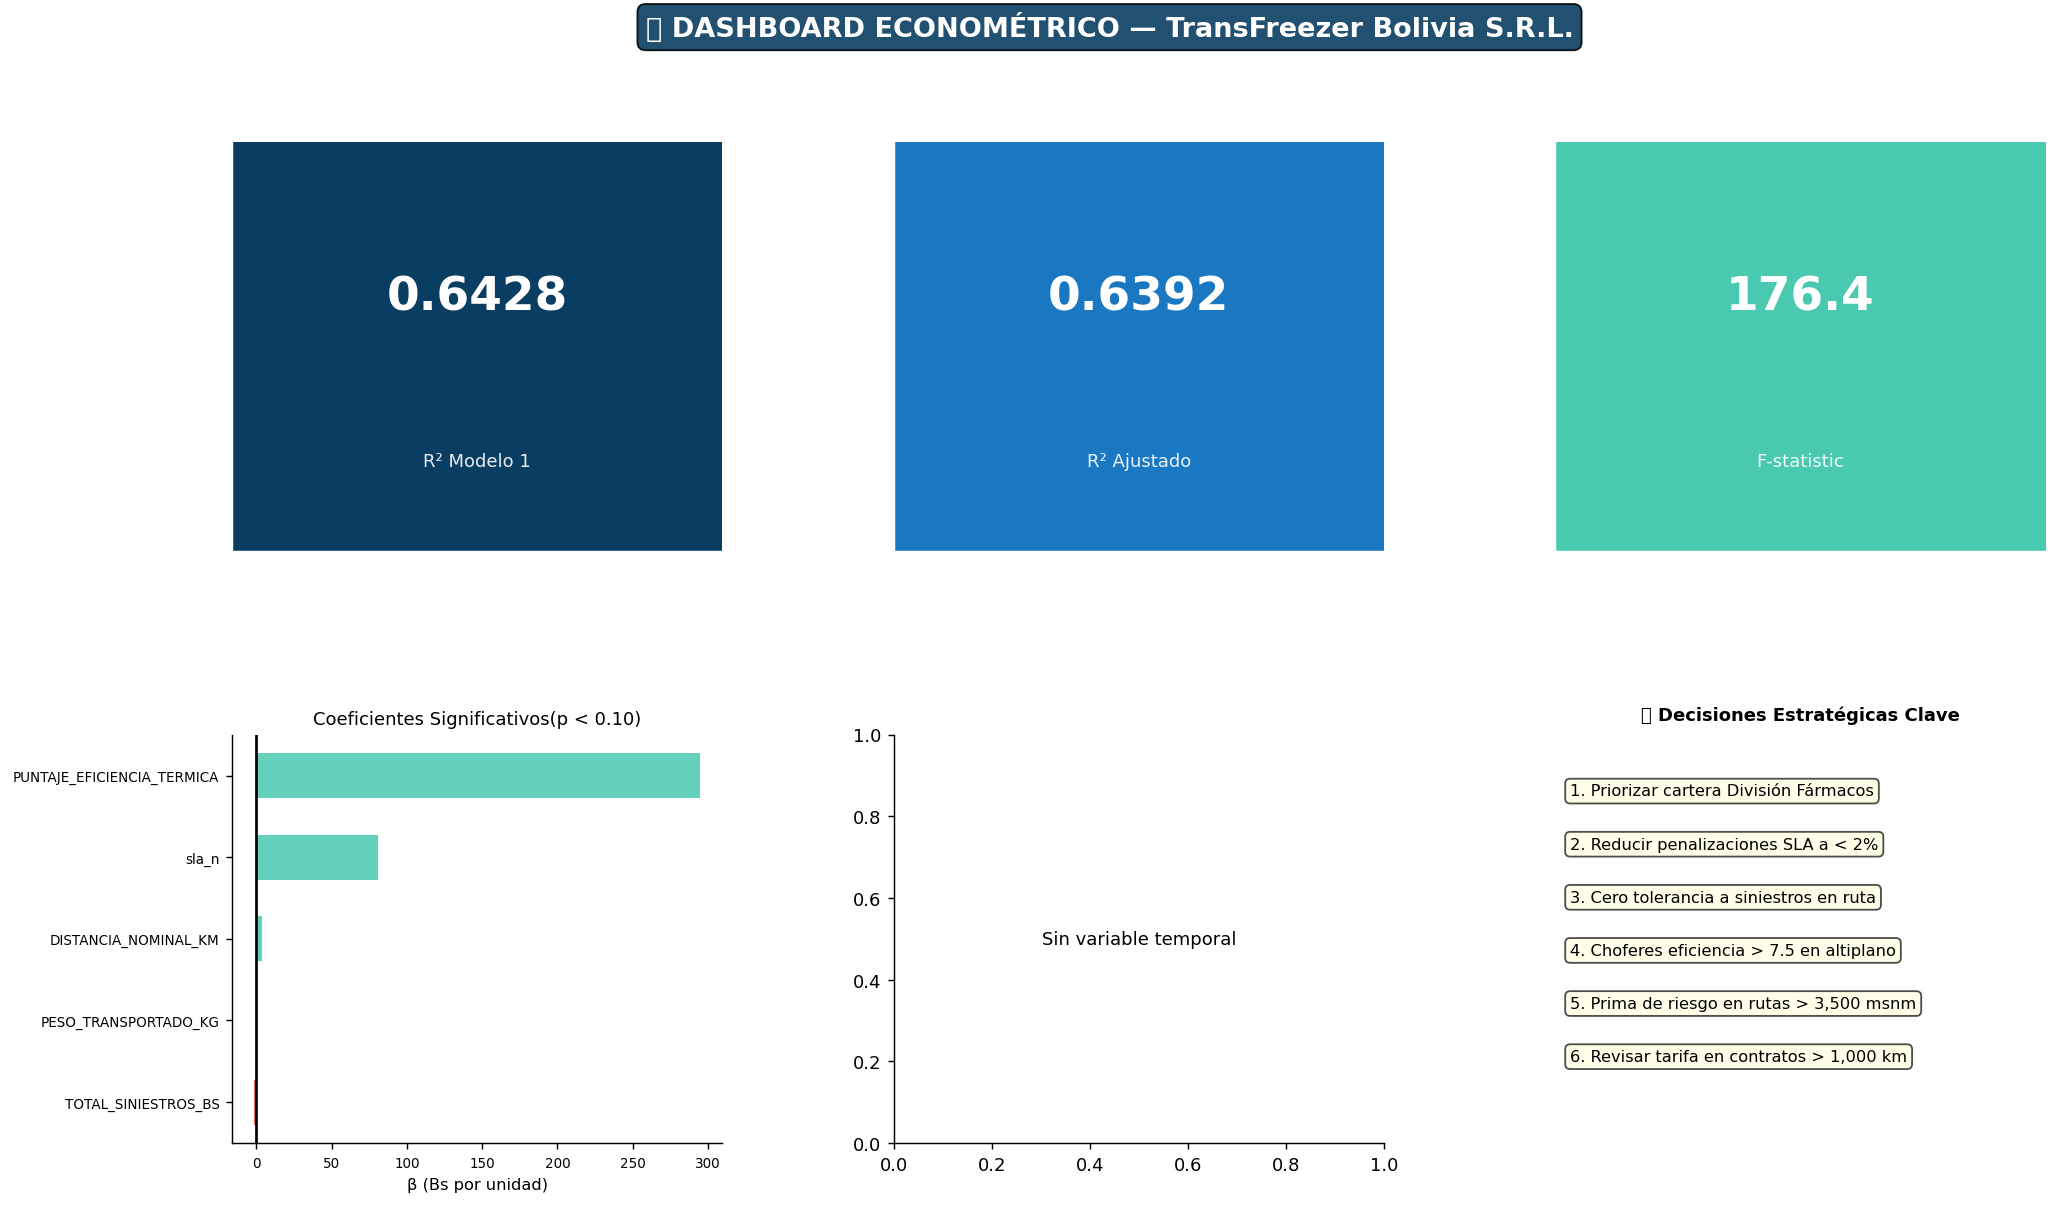

✅ Dashboard generado.


In [28]:
# ─────────────────────────────────────────────────────────────
# CELDA 5.2 — Visualización final: Dashboard de resultados
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 10))
gs  = plt.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('📊 DASHBOARD ECONOMÉTRICO — TransFreezer Bolivia S.R.L.',
             fontsize=15, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor=CORP['azul'], alpha=0.9),
             color='white')

# -- 1. KPIs del modelo ganador --
for i, (label, val, c) in enumerate([
    (f"R² Modelo 1", f"{modelo_1.rsquared:.4f}", CORP['azul']),
    (f"R² Ajustado", f"{modelo_1.rsquared_adj:.4f}", CORP['azul2']),
    (f"F-statistic", f"{modelo_1.fvalue:.1f}", CORP['teal']),
]):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(c)
    ax.text(0.5, 0.62, val,   ha='center', va='center', fontsize=26, color='white',
            fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha='center', va='center', fontsize=10,  color='white',
            alpha=0.9, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor('white')

# -- 2. Coeficientes significativos (barras horizontales) --
ax4 = fig.add_subplot(gs[1, 0])
sig_params = [(v, modelo_1.params[v], modelo_1.pvalues[v])
              for v in modelo_1.params.index
              if v != 'const' and modelo_1.pvalues[v] < 0.10]
sig_params.sort(key=lambda x: x[1])
vars_s = [x[0] for x in sig_params]
coefs_s = [x[1] for x in sig_params]
pvals_s = [x[2] for x in sig_params]
colores_s = [CORP['rojo'] if c < 0 else CORP['teal'] for c in coefs_s]
ax4.barh(vars_s, coefs_s, color=colores_s, alpha=0.85, height=0.55)
ax4.axvline(0, color='black', linewidth=1.5)
ax4.set_xlabel('β (Bs por unidad)', fontsize=9)
ax4.set_title('Coeficientes Significativos(p < 0.10)', fontsize=10)
ax4.tick_params(labelsize=7.5)

# -- 3. Evolución trimestral del margen real vs. predicho --
ax5 = fig.add_subplot(gs[1, 1])
df_trim = df_reg.copy()
df_trim['MARGEN_PREDICHO'] = modelo_1.fittedvalues
if 'ANIO' in df_trim.columns and 'TRIMESTRE' in df_trim.columns:
    df_trim_g = df_trim.groupby(['ANIO','TRIMESTRE']).agg(
        real=('MARGEN_REAL_BS','mean'), pred=('MARGEN_PREDICHO','mean')
    ).reset_index()
    df_trim_g['periodo'] = df_trim_g['ANIO'].astype(str)+'-Q'+df_trim_g['TRIMESTRE'].astype(str)
    ax5.plot(df_trim_g['periodo'], df_trim_g['real'], 'o-', color=CORP['azul2'],
             linewidth=2.5, markersize=7, label='Real')
    ax5.plot(df_trim_g['periodo'], df_trim_g['pred'], 's--', color=CORP['naranja'],
             linewidth=2, markersize=6, label='Predicho (M1)')
    ax5.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Bs {x:,.0f}'))
    ax5.set_title('Margen Real vs. Predicho por Trimestre', fontsize=10)
    ax5.legend(fontsize=8)
    ax5.tick_params(axis='x', rotation=30, labelsize=7.5)
else:
    ax5.text(0.5, 0.5, 'Sin variable temporal', ha='center', va='center',
             transform=ax5.transAxes)

# -- 4. Resumen de recomendaciones --
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
ax6.set_title('📋 Decisiones Estratégicas Clave', fontsize=10, fontweight='bold', pad=8)
recomendaciones_dash = [
    "1. Priorizar cartera División Fármacos",
    "2. Reducir penalizaciones SLA a < 2%",
    "3. Cero tolerancia a siniestros en ruta",
    "4. Choferes eficiencia > 7.5 en altiplano",
    "5. Prima de riesgo en rutas > 3,500 msnm",
    "6. Revisar tarifa en contratos > 1,000 km",
]
for i, rec in enumerate(recomendaciones_dash):
    y_pos = 0.88 - i * 0.13
    color_rec = CORP['teal'] if i % 2 == 0 else CORP['azul2']
    ax6.text(0.03, y_pos, rec, transform=ax6.transAxes, fontsize=9,
             color='black', va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))
ax6.set_xlim(0,1); ax6.set_ylim(0,1)

plt.savefig('viz_08_dashboard_final.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Dashboard generado.")


In [29]:
# ─────────────────────────────────────────────────────────────
# CELDA 5.3 — Descarga del modelo ganador con todas sus métricas
# ─────────────────────────────────────────────────────────────

import pickle, datetime

# Recopilar todo el bundle del modelo
bundle_modelo = {
    # ── Identificación ──────────────────────────────────────────
    'nombre'       : 'OLS_Margen_TransFreezer_Modelo1_Niveles',
    'version'      : '1.0.0',
    'fecha_entreno': datetime.datetime.now().isoformat(),
    'empresa'      : 'TransFreezer Bolivia S.R.L.',

    # ── Especificación ───────────────────────────────────────────
    'variable_dependiente' : 'MARGEN_REAL_BS',
    'variables_independientes': X_vars,
    'formula': 'MARGEN_REAL_BS ~ PESO_TRANSPORTADO_KG + DISTANCIA_NOMINAL_KM + '
               'ALTITUD_MAXIMA_MSNM + MONTO_PENALIZACION_BS + TOTAL_SINIESTROS_BS + '
               'sla_n + es_farma + PUNTAJE_EFICIENCIA_TERMICA',
    'metodo': 'OLS (Ordinary Least Squares) — statsmodels',

    # ── Objeto del modelo ────────────────────────────────────────
    'modelo'       : modelo_1,
    'modelo_loglog': modelo_2,

    # ── Métricas de bondad de ajuste ─────────────────────────────
    'metricas': {
        'R2'               : round(modelo_1.rsquared, 6),
        'R2_ajustado'      : round(modelo_1.rsquared_adj, 6),
        'AIC'              : round(modelo_1.aic, 4),
        'BIC'              : round(modelo_1.bic, 4),
        'F_statistic'      : round(modelo_1.fvalue, 4),
        'F_pvalue'         : round(modelo_1.f_pvalue, 6),
        'N_observaciones'  : int(modelo_1.nobs),
        'Log_likelihood'   : round(modelo_1.llf, 4),
    },

    # ── Coeficientes completos ────────────────────────────────────
    'coeficientes': {
        var: {
            'beta'    : round(float(modelo_1.params[var]), 6),
            'std_err' : round(float(modelo_1.bse[var]), 6),
            't_stat'  : round(float(modelo_1.tvalues[var]), 4),
            'p_value' : round(float(modelo_1.pvalues[var]), 6),
            'CI_95_lo': round(float(modelo_1.conf_int().loc[var, 0]), 6),
            'CI_95_hi': round(float(modelo_1.conf_int().loc[var, 1]), 6),
            'significativo_5pct': bool(modelo_1.pvalues[var] < 0.05),
        }
        for var in modelo_1.params.index
    },

    # ── Diagnóstico de supuestos ──────────────────────────────────
    'diagnostico': {
        'n_vars_significativas_5pct': int(sum(1 for p in modelo_1.pvalues if p < 0.05)),
        'n_vars_significativas_10pct': int(sum(1 for p in modelo_1.pvalues if p < 0.10)),
        'test_Breusch_Pagan_pvalue': round(float(het_breuschpagan(modelo_1.resid, X_m1_const)[1]), 4),
        'RMSE': round(float(np.sqrt(np.mean(modelo_1.resid**2))), 4),
        'MAE' : round(float(np.mean(np.abs(modelo_1.resid))), 4),
    },

    # ── Estadísticas del dataset ──────────────────────────────────
    'dataset_info': {
        'n_contratos'      : len(df_reg),
        'margen_media_bs'  : round(df_reg['MARGEN_REAL_BS'].mean(), 2),
        'margen_mediana_bs': round(df_reg['MARGEN_REAL_BS'].median(), 2),
        'margen_std_bs'    : round(df_reg['MARGEN_REAL_BS'].std(), 2),
        'margen_min_bs'    : round(df_reg['MARGEN_REAL_BS'].min(), 2),
        'margen_max_bs'    : round(df_reg['MARGEN_REAL_BS'].max(), 2),
    },

    # ── Medias de variables X (para usar en predicciones futuras) ─
    'medias_X': {v: round(float(df_reg[v].mean()), 4) for v in X_vars},
    'stds_X'  : {v: round(float(df_reg[v].std()),  4) for v in X_vars},
}

# Guardar como pickle
nombre_archivo = f"transfreezer_modelo_econometrico_v1.pkl"
with open(nombre_archivo, 'wb') as f:
    pickle.dump(bundle_modelo, f)

print(f"✅ Modelo guardado como: {nombre_archivo}")
print(f"   Tamaño: {os.path.getsize(nombre_archivo) / 1024:.1f} KB")

# Verificar que se puede cargar
with open(nombre_archivo, 'rb') as f:
    bundle_verificacion = pickle.load(f)
print(f"   Verificación de carga: ✅")
print(f"   Variables en bundle   : {list(bundle_verificacion.keys())}")

# Descarga en Google Colab
try:
    from google.colab import files
    files.download(nombre_archivo)
    print(f"\n⬇️  Descarga iniciada: {nombre_archivo}")
except ImportError:
    print(f"\nℹ️  Para descargar en Colab, ejecuta:")
    print(f"   from google.colab import files; files.download('{nombre_archivo}')")


✅ Modelo guardado como: transfreezer_modelo_econometrico_v1.pkl
   Tamaño: 346.5 KB
   Verificación de carga: ✅
   Variables en bundle   : ['nombre', 'version', 'fecha_entreno', 'empresa', 'variable_dependiente', 'variables_independientes', 'formula', 'metodo', 'modelo', 'modelo_loglog', 'metricas', 'coeficientes', 'diagnostico', 'dataset_info', 'medias_X', 'stds_X']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⬇️  Descarga iniciada: transfreezer_modelo_econometrico_v1.pkl


In [30]:
# ─────────────────────────────────────────────────────────────
# CELDA 5.4 — Función de predicción para uso en producción
# ─────────────────────────────────────────────────────────────

def predecir_margen_contrato(
    peso_kg          : float,
    distancia_km     : float,
    altitud_msnm     : float,
    penalizacion_bs  : float,
    siniestros_bs    : float,
    nivel_sla        : str,
    es_division_farma: bool,
    puntaje_chofer   : float,
    modelo_bundle    : dict = None
) -> dict:
    """
    Predice el margen real esperado de un contrato TransFreezer.

    Parámetros
    ----------
    peso_kg          : Peso total transportado en kg
    distancia_km     : Distancia nominal de la ruta en km
    altitud_msnm     : Altitud máxima de la ruta en msnm
    penalizacion_bs  : Penalización SLA estimada en Bs
    siniestros_bs    : Pérdida estimada por siniestros en Bs
    nivel_sla        : 'ESTÁNDAR', 'ORO' o 'PLATINO'
    es_division_farma: True si es contrato de División Fármacos
    puntaje_chofer   : Puntaje de eficiencia térmica del chofer (6.5 – 9.3)
    modelo_bundle    : Bundle del modelo (opcional; usa el global si None)

    Retorna
    -------
    dict con predicción, intervalo de confianza y señales de alerta
    """
    if modelo_bundle is None:
        modelo_bundle = bundle_modelo

    modelo   = modelo_bundle['modelo']
    sla_map  = {'ESTÁNDAR': 1, 'ESTANDAR': 1, 'ORO': 2, 'PLATINO': 3}
    sla_n    = sla_map.get(nivel_sla.upper().strip(), 1)
    es_farma = int(es_division_farma)

    X_nuevo = pd.DataFrame([{
        'const'                      : 1,
        'PESO_TRANSPORTADO_KG'       : peso_kg,
        'DISTANCIA_NOMINAL_KM'       : distancia_km,
        'ALTITUD_MAXIMA_MSNM'        : altitud_msnm,
        'MONTO_PENALIZACION_BS'      : penalizacion_bs,
        'TOTAL_SINIESTROS_BS'        : siniestros_bs,
        'sla_n'                      : sla_n,
        'es_farma'                   : es_farma,
        'PUNTAJE_EFICIENCIA_TERMICA' : puntaje_chofer,
    }])

    prediccion = modelo.predict(X_nuevo)[0]

    # Intervalo de predicción (± 1.96 × RMSE)
    rmse = modelo_bundle['diagnostico']['RMSE']
    ci_lo = prediccion - 1.96 * rmse
    ci_hi = prediccion + 1.96 * rmse

    # Señales de alerta
    alertas = []
    if penalizacion_bs > 500: alertas.append("⚠️ Penalización SLA elevada")
    if siniestros_bs   > 0:   alertas.append("🚨 Siniestro registrado en este contrato")
    if altitud_msnm    > 3500:alertas.append("🏔️ Ruta de alta altitud — riesgo térmico elevado")
    if puntaje_chofer  < 7.0: alertas.append("👤 Puntaje del chofer por debajo del umbral recomendado")
    if prediccion < 0:        alertas.append("❌ CONTRATO PROYECTADO CON PÉRDIDA")

    return {
        'margen_predicho_bs'   : round(prediccion, 2),
        'intervalo_confianza_95': (round(ci_lo, 2), round(ci_hi, 2)),
        'nivel_sla'            : nivel_sla,
        'division'             : 'FÁRMACOS' if es_farma else 'ALIMENTOS',
        'alertas'              : alertas,
        'rentable'             : prediccion > 0,
    }


# ── Ejemplo de uso ─────────────────────────────────────────────
print("=" * 60)
print("  🧮 EJEMPLO DE USO — FUNCIÓN DE PREDICCIÓN")
print("=" * 60)

# Tres contratos representativos
contratos_ejemplo = [
    ("Contrato Farma · SCZ-La Paz · Platino",
     dict(peso_kg=50, distancia_km=860, altitud_msnm=4200, penalizacion_bs=0,
          siniestros_bs=0, nivel_sla='PLATINO', es_division_farma=True, puntaje_chofer=8.5)),
    ("Contrato Cárnico · SCZ-Cobija · Estándar (con penalización)",
     dict(peso_kg=5000, distancia_km=1300, altitud_msnm=250, penalizacion_bs=800,
          siniestros_bs=200, nivel_sla='ESTÁNDAR', es_division_farma=False, puntaje_chofer=6.9)),
    ("Contrato Alimentos · SCZ-Cbba · Estándar",
     dict(peso_kg=2500, distancia_km=480, altitud_msnm=3500, penalizacion_bs=0,
          siniestros_bs=0, nivel_sla='ESTÁNDAR', es_division_farma=False, puntaje_chofer=7.8)),
]

for nombre, kwargs in contratos_ejemplo:
    resultado = predecir_margen_contrato(**kwargs)
    print(f"\n  📦 {nombre}")
    print(f"     Margen predicho : Bs {resultado['margen_predicho_bs']:>10,.2f}")
    print(f"     IC 95%          : [ Bs {resultado['intervalo_confianza_95'][0]:>9,.2f}  —  Bs {resultado['intervalo_confianza_95'][1]:>9,.2f} ]")
    print(f"     Rentable        : {'✅ Sí' if resultado['rentable'] else '❌ No'}")
    if resultado['alertas']:
        for a in resultado['alertas']:
            print(f"     Alerta          : {a}")

print("\n✅ Notebook completado. Revisa los archivos generados:")
print("   - viz_01 a viz_08 : Gráficos exportados como PNG")
print("   - transfreezer_modelo_econometrico_v1.pkl : Modelo serializado")


  🧮 EJEMPLO DE USO — FUNCIÓN DE PREDICCIÓN

  📦 Contrato Farma · SCZ-La Paz · Platino
     Margen predicho : Bs   3,273.72
     IC 95%          : [ Bs    892.40  —  Bs  5,655.04 ]
     Rentable        : ✅ Sí
     Alerta          : 🏔️ Ruta de alta altitud — riesgo térmico elevado

  📦 Contrato Cárnico · SCZ-Cobija · Estándar (con penalización)
     Margen predicho : Bs   3,275.79
     IC 95%          : [ Bs    894.48  —  Bs  5,657.11 ]
     Rentable        : ✅ Sí
     Alerta          : ⚠️ Penalización SLA elevada
     Alerta          : 🚨 Siniestro registrado en este contrato
     Alerta          : 👤 Puntaje del chofer por debajo del umbral recomendado

  📦 Contrato Alimentos · SCZ-Cbba · Estándar
     Margen predicho : Bs   1,283.88
     IC 95%          : [ Bs -1,097.44  —  Bs  3,665.19 ]
     Rentable        : ✅ Sí

✅ Notebook completado. Revisa los archivos generados:
   - viz_01 a viz_08 : Gráficos exportados como PNG
   - transfreezer_modelo_econometrico_v1.pkl : Modelo serializado
